# Copa 2026 — MoE + Markov LIMPO para Brasil × Japão

Esta versão corrige três problemas metodológicos:

1. **População comparável**: filtra o universo para seleções da Copa 2026, removendo equipes não comparáveis como Székely Land, Elba Island, Tamil Eelam, Isle of Man etc.
2. **Sem vazamento de elenco/2026**: features de elenco de 2026 não entram no treino histórico; performance de 2026 é calculada somente `as-of`, isto é, com partidas anteriores à data usada.
3. **MoE regularizado**: evita colapso em um único par de experts usando validação temporal + penalização de concentração + limite máximo de peso por par.


In [1]:
pip install pandas numpy scipy scikit-learn optuna optuna-dashboard joblib tqdm matplotlib plotly pyarrow openpyxl python-dateutil prophet torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import math
import re
import unicodedata
import warnings
from itertools import combinations

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import optuna
    OPTUNA_OK = True
except Exception as e:
    OPTUNA_OK = False
    print("Optuna indisponível; será usado fallback sem otimização:", e)

try:
    from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, HuberRegressor
    from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler, RobustScaler
    SKLEARN_OK = True
except Exception as e:
    SKLEARN_OK = False
    print("sklearn indisponível:", e)

try:
    from prophet import Prophet
    PROPHET_OK = True
except Exception as e:
    PROPHET_OK = False
    print("Prophet indisponível; o notebook usará fallback ponderado:", e)

try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
except Exception as e:
    TORCH_OK = False
    print("PyTorch indisponível; LSTM residual será desligada:", e)

ETL_ROOT = Path.cwd()
GOLD_DIR = ETL_ROOT / "data" / "gold"
RAW_DIR = ETL_ROOT / "data" / "raw"
OUT_DIR = GOLD_DIR / "hybrid_forecasting_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ETL_ROOT:", ETL_ROOT)
print("GOLD_DIR:", GOLD_DIR)
print("OUT_DIR:", OUT_DIR)
print("Optuna OK:", OPTUNA_OK)
print("Prophet OK:", PROPHET_OK)


ETL_ROOT: /home/perri/Área de trabalho/copa/copa_local_etl_scripts
GOLD_DIR: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold
OUT_DIR: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs
Optuna OK: True
Prophet OK: True


## 1. Configuração do jogo-alvo

O jogo-alvo fica parametrizado aqui. Pela tabela da Copa, Brasil está no **Grupo C** e Japão no **Grupo F**. No chaveamento do PDF, o confronto equivalente é **1º C × 2º F**, em **29/jun** na segunda fase/16-avos. O arquivo de referência da pipeline também marca **Brasil × Japão, round of 32, 29/06/2026, Houston**.

In [3]:
HOME_TEAM = "Brazil"
AWAY_TEAM = "Japan"
MATCH_DATE = pd.Timestamp("2026-06-29")
STAGE = "round of 32"
NEUTRAL_SITE = 1
KNOCKOUT = True
P_PEN_HOME = 0.50

# Pesos pedidos: 2026 e desempenho recente têm mais peso.
YEAR_WEIGHTS = {
    2022: 0.70,
    2023: 0.85,
    2024: 1.00,
    2025: 1.20,
    2026: 1.65,
}
RECENCY_HALFLIFE_DAYS = 420
PERFORMANCE_WEIGHT_ALPHA = 0.35

ROLLING_WINDOWS = [3, 5, 10]
N_MONTE_CARLO = 30000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Helpers de normalização e carregamento

In [4]:
def clean_text(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    return re.sub(r"\s+", " ", str(x).replace("\xa0", " ")).strip()


def norm_key(x):
    s = clean_text(x)
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

TEAM_ALIASES = {
    "brasil": "Brazil",
    "brazil": "Brazil",
    "japao": "Japan",
    "japan": "Japan",
    "holanda": "Netherlands",
    "netherlands": "Netherlands",
    "estados unidos": "United States",
    "usa": "United States",
    "united states": "United States",
    "coreia do sul": "South Korea",
    "south korea": "South Korea",
    "korea republic": "South Korea",
    "republic of korea": "South Korea",
    "marrocos": "Morocco",
    "morocco": "Morocco",
    "escocia": "Scotland",
    "scotland": "Scotland",
    "tunisia": "Tunisia",
    "tunisia": "Tunisia",
    "portugal": "Portugal",
    "argentina": "Argentina",
    "france": "France",
    "franca": "France",
    "spain": "Spain",
    "espanha": "Spain",
    "germany": "Germany",
    "alemanha": "Germany",
}

def canonical_team(x):
    raw = clean_text(x)
    if not raw:
        return ""
    return TEAM_ALIASES.get(norm_key(raw), raw)


def read_csv_if_exists(name, required=False):
    p = GOLD_DIR / name
    if not p.exists():
        if required:
            raise FileNotFoundError(f"Arquivo obrigatório não encontrado: {p}")
        print(f"[opcional ausente] {name}")
        return pd.DataFrame()
    df = pd.read_csv(p)
    print(f"[ok] {name}: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
    return df


def safe_to_datetime(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=False)


def to_numeric_safe(s, default=np.nan):
    return pd.to_numeric(s, errors="coerce").fillna(default)


## 3. Carregar todos os arquivos GOLD disponíveis

In [5]:
players = read_csv_if_exists("worldcup_2026_player_profile_features.csv")
if players.empty:
    players = read_csv_if_exists("gold_worldcup_players_2026_fifa_official.csv")

team_profile = read_csv_if_exists("worldcup_2026_team_profile_features.csv")
club_dist = read_csv_if_exists("worldcup_2026_club_distribution.csv")

matches = read_csv_if_exists("team_matches_2022_2026_free_sources.csv", required=True)
fixtures = read_csv_if_exists("team_matches_2022_2026_unique_fixtures.csv")
goal_scorers = read_csv_if_exists("team_goal_scorers_2022_2026_free_sources.csv")

# Arquivos criados pelo notebook de EDA de gols, se existirem.
goals_team_summary = read_csv_if_exists("goals_team_summary_2022_2026.csv")
goals_context = read_csv_if_exists("goals_by_team_context_wide.csv")
goals_yearly = read_csv_if_exists("goals_team_yearly_2022_2026.csv")

# Liga por clube, opcional. Se não existir, o notebook cria uma base vazia.
club_leagues_path = GOLD_DIR / "club_leagues_manual.csv"
if club_leagues_path.exists():
    club_leagues = pd.read_csv(club_leagues_path)
    print(f"[ok] club_leagues_manual.csv: {club_leagues.shape}")
else:
    club_leagues = pd.DataFrame(columns=["club", "league", "country"])
    club_leagues.to_csv(club_leagues_path, index=False)
    print("[criado] data/gold/club_leagues_manual.csv — preencha liga por clube se quiser usar mesma liga com peso 0.5")


[ok] worldcup_2026_player_profile_features.csv: 1,248 linhas × 57 colunas
[ok] worldcup_2026_team_profile_features.csv: 48 linhas × 28 colunas
[ok] worldcup_2026_club_distribution.csv: 823 linhas × 5 colunas
[ok] team_matches_2022_2026_free_sources.csv: 9,256 linhas × 40 colunas
[ok] team_matches_2022_2026_unique_fixtures.csv: 4,628 linhas × 14 colunas
[ok] team_goal_scorers_2022_2026_free_sources.csv: 2,467 linhas × 7 colunas
[opcional ausente] goals_team_summary_2022_2026.csv
[opcional ausente] goals_by_team_context_wide.csv
[opcional ausente] goals_team_yearly_2022_2026.csv
[ok] club_leagues_manual.csv: (408, 3)


## 4. Padronizar partidas em formato longo por seleção

O arquivo `team_matches_2022_2026_free_sources.csv` já vem no formato **uma linha por seleção por jogo**. Aqui garantimos nomes, datas, gols, resultado e contexto.

In [6]:
# ============================================================
# Padronização + filtro de universo comparável
# ============================================================

USE_ONLY_WORLD_CUP_2026_TEAMS = True
STRICT_BOTH_TEAMS_IN_UNIVERSE = True

# Fallback caso o CSV de jogadores não tenha country_en.
FALLBACK_WORLD_CUP_2026_TEAMS = [
    "Mexico", "South Africa", "South Korea", "Czechia",
    "Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland",
    "Brazil", "Morocco", "Haiti", "Scotland",
    "United States", "Paraguay", "Australia", "Turkey",
    "Germany", "Curaçao", "Ivory Coast", "Ecuador",
    "Netherlands", "Japan", "Sweden", "Tunisia",
    "Belgium", "Egypt", "Iran", "New Zealand",
    "Spain", "Cape Verde", "Saudi Arabia", "Uruguay",
    "France", "Senegal", "Iraq", "Norway",
    "Argentina", "Algeria", "Austria", "Jordan",
    "Portugal", "DR Congo", "Uzbekistan", "Colombia",
    "England", "Croatia", "Ghana", "Panama",
]

def standardize_matches(df):
    out = df.copy()
    rename = {}
    for c in out.columns:
        cl = c.lower().strip()
        if cl in ["data", "date", "match_date"]:
            rename[c] = "match_date"
        elif cl in ["team", "team_name", "selection", "selecao", "seleção"]:
            rename[c] = "team_name"
        elif cl in ["opponent", "adversario", "adversário"]:
            rename[c] = "opponent"
        elif cl in ["goals_for", "gf", "gols_pro", "gols_pró"]:
            rename[c] = "goals_for"
        elif cl in ["goals_against", "ga", "gols_contra"]:
            rename[c] = "goals_against"
        elif cl in ["competition", "competicao", "competição", "tournament"]:
            rename[c] = "competition"
    out = out.rename(columns=rename)

    needed = ["match_date", "team_name", "opponent", "goals_for", "goals_against"]
    missing = [c for c in needed if c not in out.columns]
    if missing:
        raise ValueError(f"matches sem colunas obrigatórias: {missing}. Colunas disponíveis: {list(out.columns)}")

    out["match_date"] = safe_to_datetime(out["match_date"])
    out = out.dropna(subset=["match_date"]).copy()
    out["team_name"] = out["team_name"].map(canonical_team)
    out["opponent"] = out["opponent"].map(canonical_team)
    out["team_key"] = out["team_name"].map(norm_key)
    out["opponent_key"] = out["opponent"].map(norm_key)
    out["goals_for"] = pd.to_numeric(out["goals_for"], errors="coerce")
    out["goals_against"] = pd.to_numeric(out["goals_against"], errors="coerce")
    out = out.dropna(subset=["goals_for", "goals_against"]).copy()
    out["goals_for"] = out["goals_for"].astype(int)
    out["goals_against"] = out["goals_against"].astype(int)
    out["goal_diff"] = out["goals_for"] - out["goals_against"]

    if "competition" not in out.columns:
        out["competition"] = ""
    out["competition"] = out["competition"].fillna("").map(clean_text)

    if "result" not in out.columns:
        out["result"] = np.select(
            [out["goal_diff"] > 0, out["goal_diff"] < 0],
            ["W", "L"],
            default="D",
        )
    out["result_norm"] = out["result"].astype(str).str.upper().str[0].map({"W": "win", "D": "draw", "L": "loss"}).fillna("draw")
    out["is_win"] = (out["result_norm"] == "win").astype(int)
    out["is_draw"] = (out["result_norm"] == "draw").astype(int)
    out["is_loss"] = (out["result_norm"] == "loss").astype(int)
    out["points"] = out["is_win"] * 3 + out["is_draw"]
    out["clean_sheet"] = (out["goals_against"] == 0).astype(int)
    out["failed_to_score"] = (out["goals_for"] == 0).astype(int)
    out["total_goals"] = out["goals_for"] + out["goals_against"]
    out["over_25"] = (out["total_goals"] >= 3).astype(int)

    if "is_friendly" not in out.columns:
        comp = out["competition"].astype(str).str.lower()
        out["is_friendly"] = comp.str.contains("friendly|amistoso").astype(int)
    else:
        out["is_friendly"] = pd.to_numeric(out["is_friendly"], errors="coerce").fillna(0).astype(int)

    if "neutral" not in out.columns:
        out["neutral"] = 0
    out["neutral"] = pd.to_numeric(out["neutral"], errors="coerce").fillna(0).astype(int)

    if "is_home" not in out.columns:
        out["is_home"] = 0
    out["is_home"] = pd.to_numeric(out["is_home"], errors="coerce").fillna(0).astype(int)

    # Chave pareada de jogo estável para juntar adversário.
    pair = out.apply(lambda r: "__".join(sorted([r["team_key"], r["opponent_key"]])), axis=1)
    out["match_key"] = out["match_date"].dt.strftime("%Y%m%d") + "__" + pair
    out["year"] = out["match_date"].dt.year
    out["month"] = out["match_date"].dt.month
    return out.sort_values(["team_key", "match_date", "opponent_key"]).reset_index(drop=True)


def infer_world_cup_2026_team_keys(players_df):
    teams = []
    if players_df is not None and not players_df.empty:
        if "country_en" in players_df.columns:
            teams = players_df["country_en"].dropna().map(canonical_team).unique().tolist()
        elif "team_name" in players_df.columns:
            teams = players_df["team_name"].dropna().map(canonical_team).unique().tolist()
    if not teams:
        teams = FALLBACK_WORLD_CUP_2026_TEAMS
    # Garante o jogo-alvo mesmo se algum CSV vier incompleto.
    teams = sorted(set(teams + [HOME_TEAM, AWAY_TEAM]))
    return {norm_key(t) for t in teams if clean_text(t)}


def classify_competition_tier(comp):
    k = norm_key(comp)
    if "friendly" in k or "amistoso" in k:
        return "friendly"
    if "fifa world cup" in k or "world cup" in k:
        return "world_cup"
    if "qualif" in k or "qualification" in k or "qualifier" in k or "eliminat" in k:
        return "qualifier"
    if any(x in k for x in ["copa america", "euro", "africa cup", "asian cup", "gold cup", "nations cup", "uefa nations"]):
        return "continental_or_nations"
    return "other_competitive"


def filter_to_comparable_universe(df, players_df):
    before_rows = len(df)
    before_teams = pd.Index(pd.concat([df["team_key"], df["opponent_key"]]).dropna().unique())

    cup_keys = infer_world_cup_2026_team_keys(players_df)

    out = df.copy()
    out["competition_tier"] = out["competition"].map(classify_competition_tier)

    if USE_ONLY_WORLD_CUP_2026_TEAMS:
        if STRICT_BOTH_TEAMS_IN_UNIVERSE:
            mask = out["team_key"].isin(cup_keys) & out["opponent_key"].isin(cup_keys)
        else:
            mask = out["team_key"].isin(cup_keys)
        out = out[mask].copy()

    # Peso por equivalência competitiva. Amistosos ficam, mas contam menos.
    comp_weight_map = {
        "world_cup": 1.35,
        "qualifier": 1.15,
        "continental_or_nations": 1.05,
        "other_competitive": 0.95,
        "friendly": 0.55,
    }
    out["competition_weight"] = out["competition_tier"].map(comp_weight_map).fillna(0.85)

    after_teams = pd.Index(pd.concat([out["team_key"], out["opponent_key"]]).dropna().unique())
    removed = sorted(set(before_teams) - set(after_teams))

    report = pd.DataFrame([{
        "before_rows": int(before_rows),
        "after_rows": int(len(out)),
        "before_unique_teams": int(len(before_teams)),
        "after_unique_teams": int(len(after_teams)),
        "world_cup_team_keys": int(len(cup_keys)),
        "strict_both_teams": bool(STRICT_BOTH_TEAMS_IN_UNIVERSE),
        "removed_examples": ", ".join(removed[:80]),
    }])

    report.to_csv(OUT_DIR / "universe_filter_report.csv", index=False)

    removed_df = pd.DataFrame({"removed_team_key": removed})
    removed_df.to_csv(OUT_DIR / "universe_removed_teams.csv", index=False)

    if len(out) < 50:
        raise ValueError(
            "O filtro de universo comparável deixou menos de 50 linhas. "
            "Verifique se players/country_en tem as seleções da Copa 2026 ou mude STRICT_BOTH_TEAMS_IN_UNIVERSE=False."
        )

    return out.sort_values(["team_key", "match_date", "opponent_key"]).reset_index(drop=True), report


long_raw = standardize_matches(matches)
long, universe_report = filter_to_comparable_universe(long_raw, players)

print("Filtro de universo comparável aplicado.")
display(universe_report)
print("Shape long filtrado:", long.shape)
display(long.head())


Filtro de universo comparável aplicado.


,before_rows,after_rows,before_unique_teams,after_unique_teams,world_cup_team_keys,strict_both_teams,removed_examples
0,9256,1174,262,46,48,True,"afghanistan, aland islands, albania, alderney,..."


Shape long filtrado: (1174, 56)


,fixture_id_open,match_date,team_name,team_key_norm,opponent,opponent_key_norm,is_home,home_team,away_team,home_score,...,points,clean_sheet,failed_to_score,total_goals,over_25,match_key,year,month,competition_tier,competition_weight
0,20220105__algeria__ghana__3_0__friendly,2022-01-05,Algeria,algeria,Ghana,ghana,1,Algeria,Ghana,3,...,3,1,0,3,1,20220105__algeria__ghana,2022,1,friendly,0.55
1,20220120__ivory coast__algeria__3_1__african c...,2022-01-20,Algeria,algeria,Ivory Coast,ivory coast,0,Ivory Coast,Algeria,3,...,0,0,0,4,1,20220120__algeria__ivory coast,2022,1,other_competitive,0.95
2,20220612__iran__algeria__1_2__friendly,2022-06-12,Algeria,algeria,Iran,iran,0,Iran,Algeria,1,...,3,0,0,3,1,20220612__algeria__iran,2022,6,friendly,0.55
3,20221119__sweden__algeria__2_0__friendly,2022-11-19,Algeria,algeria,Sweden,sweden,0,Sweden,Algeria,2,...,0,0,1,2,0,20221119__algeria__sweden,2022,11,friendly,0.55
4,20230620__algeria__tunisia__1_1__friendly,2023-06-20,Algeria,algeria,Tunisia,tunisia,1,Algeria,Tunisia,1,...,1,0,0,2,0,20230620__algeria__tunisia,2023,6,friendly,0.55


## 5. Features sem vazamento: rolling com `shift(1)`

Essas features são calculadas por seleção, mas sempre usando apenas jogos anteriores. Isso evita treinar o modelo com informação do próprio jogo.

In [7]:
def rolling_shifted_mean(df, col, window):
    shifted = df.groupby("team_key")[col].shift(1)
    return shifted.groupby(df["team_key"]).rolling(window, min_periods=max(2, window // 2)).mean().reset_index(level=0, drop=True)


def rolling_shifted_sum(df, col, window):
    shifted = df.groupby("team_key")[col].shift(1)
    return shifted.groupby(df["team_key"]).rolling(window, min_periods=max(2, window // 2)).sum().reset_index(level=0, drop=True)


def add_rolling_features(df):
    out = df.sort_values(["team_key", "match_date"]).copy()
    out["days_since_last"] = out.groupby("team_key")["match_date"].diff().dt.days
    out["prev_match_date"] = out.groupby("team_key")["match_date"].shift(1)

    for w in ROLLING_WINDOWS:
        out[f"gf_avg_{w}"] = rolling_shifted_mean(out, "goals_for", w)
        out[f"ga_avg_{w}"] = rolling_shifted_mean(out, "goals_against", w)
        out[f"gd_avg_{w}"] = out[f"gf_avg_{w}"] - out[f"ga_avg_{w}"]
        out[f"points_avg_{w}"] = rolling_shifted_mean(out, "points", w)
        out[f"win_rate_{w}"] = rolling_shifted_mean(out, "is_win", w)
        out[f"loss_rate_{w}"] = rolling_shifted_mean(out, "is_loss", w)
        out[f"clean_sheet_rate_{w}"] = rolling_shifted_mean(out, "clean_sheet", w)
        out[f"failed_score_rate_{w}"] = rolling_shifted_mean(out, "failed_to_score", w)
        out[f"over25_rate_{w}"] = rolling_shifted_mean(out, "over_25", w)

    # Média histórica acumulada até antes do jogo.
    for col in ["goals_for", "goals_against", "goal_diff", "points", "is_win", "is_loss"]:
        shifted = out.groupby("team_key")[col].shift(1)
        out[f"cum_{col}_avg"] = shifted.groupby(out["team_key"]).expanding(min_periods=2).mean().reset_index(level=0, drop=True)

    return out

long_feat = add_rolling_features(long)
display(long_feat[["match_date", "team_name", "opponent", "goals_for", "goals_against", "gf_avg_5", "ga_avg_5", "win_rate_5", "points_avg_5"]].head(12))


,match_date,team_name,opponent,goals_for,goals_against,gf_avg_5,ga_avg_5,win_rate_5,points_avg_5
0,2022-01-05,Algeria,Ghana,3,0,NaN,NaN,NaN,NaN
1,2022-01-20,Algeria,Ivory Coast,1,3,NaN,NaN,NaN,NaN
2,2022-06-12,Algeria,Iran,2,1,2.0,1.500000,0.500000,1.5
3,2022-11-19,Algeria,Sweden,0,2,2.0,1.333333,0.666667,2.0
4,2023-06-20,Algeria,Tunisia,1,1,1.5,1.500000,0.500000,1.5
5,2023-09-12,Algeria,Senegal,1,0,1.4,1.400000,0.400000,1.4
6,2023-10-16,Algeria,Egypt,1,1,1.0,1.400000,0.400000,1.4
7,2024-03-26,Algeria,South Africa,3,3,1.0,1.000000,0.400000,1.6
8,2025-06-10,Algeria,Sweden,3,4,1.2,1.400000,0.200000,1.2
9,2025-11-18,Algeria,Saudi Arabia,2,0,1.8,1.800000,0.200000,1.2


## 6. Pesos de treino: recência + ano + desempenho em 2026

A ideia pedida é dar mais peso para times que performaram melhor no ano atual. Usamos:

- **peso por ano**: 2026 > 2025 > 2024 > 2023 > 2022;
- **peso exponencial de recência**: jogos próximos da data-alvo valem mais;
- **bônus de desempenho 2026 da seleção**: baseado em pontos por jogo e saldo médio.

In [8]:
# ============================================================
# Pesos sem vazamento: recência + ano + competição + performance as-of
# ============================================================

def add_asof_performance_features(df):
    """
    Calcula performance do ano corrente usando apenas jogos anteriores
    à própria linha. Isso evita usar informação futura de 2026 na validação.
    """
    out = df.sort_values(["team_key", "match_date", "opponent_key"]).copy()

    grp = out.groupby(["team_key", "year"], group_keys=False)
    out["matches_ytd_before"] = grp.cumcount()

    # Cumulativos antes do jogo atual.
    for src, dst in [
        ("points", "points_ytd_before"),
        ("goals_for", "gf_ytd_before"),
        ("goals_against", "ga_ytd_before"),
        ("goal_diff", "gd_ytd_before"),
        ("is_win", "wins_ytd_before"),
    ]:
        out[dst] = grp[src].cumsum() - out[src]

    denom = out["matches_ytd_before"].replace(0, np.nan)

    out["ppg_ytd_asof"] = out["points_ytd_before"] / denom
    out["gf_pg_ytd_asof"] = out["gf_ytd_before"] / denom
    out["ga_pg_ytd_asof"] = out["ga_ytd_before"] / denom
    out["gd_pg_ytd_asof"] = out["gd_ytd_before"] / denom
    out["win_rate_ytd_asof"] = out["wins_ytd_before"] / denom

    # Score em escala aproximadamente 0-1, sem normalização com dados futuros.
    ppg_component = (out["ppg_ytd_asof"] / 3.0).clip(0, 1)
    win_component = out["win_rate_ytd_asof"].clip(0, 1)
    attack_component = (out["gf_pg_ytd_asof"] / 3.0).clip(0, 1)
    defense_component = (1.0 - (out["ga_pg_ytd_asof"] / 3.0)).clip(0, 1)
    gd_component = ((out["gd_pg_ytd_asof"] + 3.0) / 6.0).clip(0, 1)

    out["performance_score_asof_norm"] = (
        0.30 * ppg_component.fillna(0.5)
        + 0.25 * win_component.fillna(0.5)
        + 0.20 * attack_component.fillna(0.5)
        + 0.15 * defense_component.fillna(0.5)
        + 0.10 * gd_component.fillna(0.5)
    ).clip(0, 1)

    return out


def compute_team_target_performance(df, as_of_date=MATCH_DATE):
    """
    Performance 2026 usada APENAS para previsão do jogo-alvo e ranking
    pré-jogo. Só considera jogos anteriores ao MATCH_DATE.
    """
    hist = df[(df["match_date"] < pd.Timestamp(as_of_date)) & (df["year"] == pd.Timestamp(as_of_date).year)].copy()

    if hist.empty:
        hist = df[df["match_date"] < pd.Timestamp(as_of_date)].copy()

    perf = (
        hist.groupby(["team_key", "team_name"], as_index=False)
        .agg(
            matches_2026=("match_key", "nunique"),
            ppg_2026=("points", "mean"),
            gf_pg_2026=("goals_for", "mean"),
            ga_pg_2026=("goals_against", "mean"),
            gd_pg_2026=("goal_diff", "mean"),
            win_rate_2026=("is_win", "mean"),
        )
    )

    if perf.empty:
        return pd.DataFrame(columns=[
            "team_key", "team_name", "matches_2026", "ppg_2026", "gf_pg_2026",
            "ga_pg_2026", "gd_pg_2026", "win_rate_2026",
            "performance_score_2026", "performance_score_2026_norm"
        ])

    ppg_component = (perf["ppg_2026"] / 3.0).clip(0, 1)
    win_component = perf["win_rate_2026"].clip(0, 1)
    attack_component = (perf["gf_pg_2026"] / 3.0).clip(0, 1)
    defense_component = (1.0 - (perf["ga_pg_2026"] / 3.0)).clip(0, 1)
    gd_component = ((perf["gd_pg_2026"] + 3.0) / 6.0).clip(0, 1)

    perf["performance_score_2026_norm"] = (
        0.30 * ppg_component.fillna(0.5)
        + 0.25 * win_component.fillna(0.5)
        + 0.20 * attack_component.fillna(0.5)
        + 0.15 * defense_component.fillna(0.5)
        + 0.10 * gd_component.fillna(0.5)
    ).clip(0, 1)

    perf["performance_score_2026"] = perf["performance_score_2026_norm"]
    return perf


def add_training_weights(df):
    out = add_asof_performance_features(df)

    # Sem vazamento: cada linha recebe peso calculado com sua própria data e features as-of.
    days_to_target = (MATCH_DATE - out["match_date"]).dt.days.clip(lower=0)
    out["recency_weight"] = np.exp(-np.log(2) * days_to_target / RECENCY_HALFLIFE_DAYS)
    out["year_weight"] = out["year"].map(YEAR_WEIGHTS).fillna(1.0)
    out["competition_weight"] = pd.to_numeric(out.get("competition_weight", 1.0), errors="coerce").fillna(1.0)
    out["team_perf_weight"] = 1.0 + PERFORMANCE_WEIGHT_ALPHA * out["performance_score_asof_norm"].fillna(0.5)

    out["sample_weight"] = (
        out["recency_weight"]
        * out["year_weight"]
        * out["competition_weight"]
        * out["team_perf_weight"]
    )

    return out


long_feat = add_training_weights(long)

team_perf_2026 = compute_team_target_performance(long, as_of_date=MATCH_DATE)
perf_map = dict(zip(team_perf_2026["team_key"], team_perf_2026["performance_score_2026_norm"]))

print("Performance 2026 calculada apenas com jogos antes de", MATCH_DATE.date())
display(team_perf_2026.sort_values("performance_score_2026_norm", ascending=False).head(15))

long_feat.to_csv(OUT_DIR / "long_features_leakage_safe.csv", index=False)


Performance 2026 calculada apenas com jogos antes de 2026-06-29


,team_key,team_name,matches_2026,ppg_2026,gf_pg_2026,ga_pg_2026,gd_pg_2026,win_rate_2026,performance_score_2026_norm,performance_score_2026
1,argentina,Argentina,2,3.000000,2.500000,0.000000,2.500000,1.000000,0.958333,0.958333
16,germany,Germany,6,2.500000,3.000000,1.500000,1.500000,0.833333,0.808333,0.808333
15,france,France,5,2.400000,2.400000,1.000000,1.400000,0.800000,0.773333,0.773333
6,brazil,Brazil,7,2.285714,2.714286,1.000000,1.714286,0.714286,0.766667,0.766667
3,austria,Austria,5,2.400000,2.000000,0.800000,1.200000,0.800000,0.753333,0.753333
24,mexico,Mexico,7,2.428571,1.142857,0.142857,1.000000,0.714286,0.707143,0.707143
21,ivory coast,Ivory Coast,7,2.142857,1.857143,0.857143,1.000000,0.714286,0.690476,0.690476
22,japan,Japan,5,2.200000,1.800000,0.600000,1.200000,0.600000,0.680000,0.680000
4,belgium,Belgium,6,2.000000,2.333333,0.666667,1.666667,0.500000,0.675000,0.675000
31,portugal,Portugal,4,2.000000,2.000000,0.250000,1.750000,0.500000,0.675000,0.675000


## 7. Features de elenco: jogadores, clubes, afinidade e liga

Aqui usamos o que foi produzido no ETL de jogadores. Criamos features agregadas por seleção e um índice de afinidade:

- pares de jogadores no mesmo clube: peso 1.0;
- pares de jogadores na mesma liga: peso 0.5;
- número de clubes únicos;
- maior concentração em um clube;
- caps e gols internacionais do elenco.

In [9]:
def build_squad_features(players_df, club_dist_df, club_leagues_df):
    if players_df.empty:
        return pd.DataFrame(columns=["team_key"])
    p = players_df.copy()
    if "country_en" not in p.columns and "team_name" in p.columns:
        p["country_en"] = p["team_name"]
    if "country_en" not in p.columns:
        return pd.DataFrame(columns=["team_key"])
    p["country_en"] = p["country_en"].map(canonical_team)
    p["team_key"] = p["country_en"].map(norm_key)
    if "player_name" not in p.columns:
        p["player_name"] = p.get("name", "")
    if "club" not in p.columns and "club_raw" in p.columns:
        p["club"] = p["club_raw"]
    if "club" not in p.columns:
        p["club"] = ""
    p["club"] = p["club"].map(clean_text)
    for col in ["caps", "international_goals", "goals", "age_at_world_cup_start", "height_cm"]:
        if col in p.columns:
            p[col] = pd.to_numeric(p[col], errors="coerce")
    if "international_goals" not in p.columns and "goals" in p.columns:
        p["international_goals"] = p["goals"]

    # liga por clube opcional
    cl = club_leagues_df.copy()
    if not cl.empty and "club" in cl.columns:
        cl["club_key"] = cl["club"].map(norm_key)
        p["club_key"] = p["club"].map(norm_key)
        p = p.merge(cl[["club_key", "league"]].drop_duplicates(), on="club_key", how="left")
    else:
        p["league"] = ""
    p["league"] = p["league"].fillna("").map(clean_text)

    rows = []
    for team_key, g in p.groupby("team_key"):
        clubs = g["club"].replace("", np.nan).dropna()
        leagues = g["league"].replace("", np.nan).dropna()
        n = len(g)
        same_club_pairs = 0
        for _, cnt in clubs.value_counts().items():
            same_club_pairs += cnt * (cnt - 1) / 2
        same_liga_pairs = 0
        for _, cnt in leagues.value_counts().items():
            same_liga_pairs += cnt * (cnt - 1) / 2
        max_pairs = max(n * (n - 1) / 2, 1)
        affinity = (1.0 * same_club_pairs + 0.5 * same_liga_pairs) / max_pairs
        rows.append({
            "team_key": team_key,
            "team_name": canonical_team(g["country_en"].iloc[0]),
            "squad_players": n,
            "squad_clubs_nunique": int(clubs.nunique()),
            "squad_top_club_players": int(clubs.value_counts().iloc[0]) if len(clubs) else 0,
            "squad_same_club_pairs": same_club_pairs,
            "squad_same_liga_pairs": same_liga_pairs,
            "squad_affinity_index": affinity,
            "squad_caps_total": g["caps"].sum() if "caps" in g else np.nan,
            "squad_caps_avg": g["caps"].mean() if "caps" in g else np.nan,
            "squad_goals_total": g["international_goals"].sum() if "international_goals" in g else np.nan,
            "squad_goals_avg": g["international_goals"].mean() if "international_goals" in g else np.nan,
            "squad_avg_age": g["age_at_world_cup_start"].mean() if "age_at_world_cup_start" in g else np.nan,
            "squad_avg_height_cm": g["height_cm"].mean() if "height_cm" in g else np.nan,
        })
    return pd.DataFrame(rows)

squad_feat = build_squad_features(players, club_dist, club_leagues)
display(squad_feat.sort_values("squad_affinity_index", ascending=False).head(15))

squad_feat.to_csv(OUT_DIR / "squad_affinity_features.csv", index=False)


,team_key,team_name,squad_players,squad_clubs_nunique,squad_top_club_players,squad_same_club_pairs,squad_same_liga_pairs,squad_affinity_index,squad_caps_total,squad_caps_avg,squad_goals_total,squad_goals_avg,squad_avg_age,squad_avg_height_cm
38,south africa,South Africa,26,12,8,56.0,0,0.172308,566,21.769231,68,2.615385,26.808846,178.846154
12,czechia,Czechia,26,11,10,54.0,0,0.166154,0,0.000000,4829,185.730769,27.621154,NaN
35,saudi arabia,Saudi Arabia,26,9,7,46.0,0,0.141538,4639,178.423077,975,37.500000,28.516923,NaN
34,qatar,Qatar,26,8,6,40.0,0,0.123077,1618,62.230769,217,8.346154,29.507692,179.384615
40,spain,Spain,26,13,8,37.0,0,0.113846,0,0.000000,790,30.384615,26.747308,181.730769
44,turkey,Turkey,26,16,6,30.0,0,0.092308,4778,183.769231,1021,39.269231,27.672308,NaN
18,germany,Germany,26,13,6,29.0,0,0.089231,892,34.307692,115,4.423077,28.046923,186.192308
25,jordan,Jordan,26,14,7,28.0,0,0.086154,1095,42.115385,92,3.538462,28.465000,180.307692
21,iran,Iran,26,14,4,20.0,0,0.061538,1221,46.961538,151,5.807692,30.333077,183.653846
29,new zealand,New Zealand,26,19,6,18.0,0,0.055385,880,33.846154,110,4.230769,28.267308,183.076923


## 8. Dataset de modelagem no nível seleção-jogo

O alvo é `goals_for`. Cada linha representa uma seleção em um jogo, com features próprias e features defasadas do adversário.

In [10]:
# ============================================================
# Dataset de modelagem sem vazamento de elenco 2026
# ============================================================

BASE_FEATURE_PREFIXES = (
    "gf_avg_", "ga_avg_", "gd_avg_", "points_avg_", "win_rate_", "loss_rate_",
    "clean_sheet_rate_", "failed_score_rate_", "over25_rate_", "cum_",
)

USE_SQUAD_FEATURES_IN_HISTORICAL_TRAINING = False

def build_model_table(df, squad_feat=None):
    out = df.copy()

    # NÃO junta squad_ no treino histórico por padrão.
    # O elenco de 2026 é conhecido para o jogo-alvo, mas não era conhecido em 2022-2025.
    if USE_SQUAD_FEATURES_IN_HISTORICAL_TRAINING and squad_feat is not None and not squad_feat.empty:
        out = out.merge(squad_feat.drop(columns=["team_name"], errors="ignore"), on="team_key", how="left")

    feature_cols_base = [c for c in out.columns if c.startswith(BASE_FEATURE_PREFIXES)]
    feature_cols_base += [
        c for c in [
            "days_since_last", "is_friendly", "neutral", "is_home", "month",
            "ppg_ytd_asof", "gf_pg_ytd_asof", "ga_pg_ytd_asof",
            "gd_pg_ytd_asof", "win_rate_ytd_asof",
            "performance_score_asof_norm", "competition_weight"
        ]
        if c in out.columns
    ]

    if USE_SQUAD_FEATURES_IN_HISTORICAL_TRAINING:
        feature_cols_base += [c for c in out.columns if c.startswith("squad_")]

    feature_cols_base = list(dict.fromkeys(feature_cols_base))

    # Base do adversário no mesmo match_key.
    opp = out[["match_key", "team_key"] + feature_cols_base].copy()
    opp = opp.rename(columns={"team_key": "opponent_key"})
    opp = opp.add_prefix("opp_").rename(columns={"opp_match_key": "match_key", "opp_opponent_key": "opponent_key"})

    m = out.merge(opp, on=["match_key", "opponent_key"], how="left")

    # Diferenciais úteis.
    for c in feature_cols_base:
        oc = f"opp_{c}"
        if c in m.columns and oc in m.columns:
            m[f"diff_{c}"] = pd.to_numeric(m[c], errors="coerce") - pd.to_numeric(m[oc], errors="coerce")

    m["target_goals_for"] = m["goals_for"]
    m["target_goals_against"] = m["goals_against"]
    return m


model_df = build_model_table(long_feat, squad_feat)

feature_cols = [c for c in model_df.columns if (
    c.startswith(BASE_FEATURE_PREFIXES)
    or c.startswith("opp_")
    or c.startswith("diff_")
    or c in [
        "days_since_last", "is_friendly", "neutral", "is_home", "month",
        "ppg_ytd_asof", "gf_pg_ytd_asof", "ga_pg_ytd_asof",
        "gd_pg_ytd_asof", "win_rate_ytd_asof",
        "performance_score_asof_norm", "competition_weight"
    ]
)]

# Remove explicitamente qualquer squad_ se treino histórico estiver desligado.
if not USE_SQUAD_FEATURES_IN_HISTORICAL_TRAINING:
    feature_cols = [c for c in feature_cols if not c.startswith("squad_") and not c.startswith("opp_squad_") and not c.startswith("diff_squad_")]

feature_cols = [c for c in feature_cols if c in model_df.columns and pd.api.types.is_numeric_dtype(model_df[c])]
feature_cols = list(dict.fromkeys(feature_cols))

print("Features numéricas sem vazamento:", len(feature_cols))
print("Usa squad no treino histórico?", USE_SQUAD_FEATURES_IN_HISTORICAL_TRAINING)
print(feature_cols[:40])
display(model_df[["match_date", "team_name", "opponent", "goals_for", "goals_against", "sample_weight"] + feature_cols[:8]].tail())


Features numéricas sem vazamento: 33
Usa squad no treino histórico? False
['is_home', 'is_friendly', 'neutral', 'month', 'competition_weight', 'ppg_ytd_asof', 'gf_pg_ytd_asof', 'ga_pg_ytd_asof', 'gd_pg_ytd_asof', 'win_rate_ytd_asof', 'performance_score_asof_norm', 'opp_win_rate_ytd_asof', 'opp_is_friendly', 'opp_neutral', 'opp_is_home', 'opp_month', 'opp_ppg_ytd_asof', 'opp_gf_pg_ytd_asof', 'opp_ga_pg_ytd_asof', 'opp_gd_pg_ytd_asof', 'opp_performance_score_asof_norm', 'opp_competition_weight', 'diff_win_rate_ytd_asof', 'diff_is_friendly', 'diff_neutral', 'diff_is_home', 'diff_month', 'diff_ppg_ytd_asof', 'diff_gf_pg_ytd_asof', 'diff_ga_pg_ytd_asof', 'diff_gd_pg_ytd_asof', 'diff_performance_score_asof_norm', 'diff_competition_weight']


,match_date,team_name,opponent,goals_for,goals_against,sample_weight,is_home,is_friendly,neutral,month,competition_weight,ppg_ytd_asof,gf_pg_ytd_asof,ga_pg_ytd_asof
1169,2025-11-18,Uzbekistan,Iran,0,0,0.938111,0,0,1,11,0.95,1.6,1.600000,0.800000
1170,2026-06-01,Uzbekistan,Canada,0,2,1.018160,0,1,0,6,0.55,NaN,NaN,NaN
1171,2026-06-08,Uzbekistan,Netherlands,1,2,0.897041,0,1,1,6,0.55,0.0,0.000000,2.000000
1172,2026-06-17,Uzbekistan,Colombia,1,3,2.266623,1,0,1,6,1.35,0.0,0.500000,2.000000
1173,2026-06-23,Uzbekistan,Portugal,0,5,2.282746,0,0,1,6,1.35,0.0,0.666667,2.333333


## 9. Modelos avançados: NNAR Poisson, Poisson Double, Full Logistic, Elo-Logistic e MoE

In [11]:
# ============================================================
# Substituição da regressão linear por arquitetura avançada:
# NNAR Poisson + Poisson Double Regression + Full Logistic
# + Elo-Logistic + MoE pairwise + Markov Chain
# ============================================================

from itertools import combinations

try:
    from sklearn.linear_model import PoissonRegressor, LogisticRegression
    from sklearn.neural_network import MLPRegressor
    from sklearn.metrics import log_loss, brier_score_loss
    from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
    SKLEARN_ADV_OK = True
except Exception as e:
    SKLEARN_ADV_OK = False
    print("sklearn avançado indisponível:", e)

try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except Exception:
    JOBLIB_OK = False

N_MOE_OPTUNA_TRIALS = 120
MAX_GOALS_MARKOV = 8
MARKOV_MINUTES = 90
N_PROPHET_MARKOV_SAMPLES = min(int(N_MONTE_CARLO), 4000) if "N_MONTE_CARLO" in globals() else 4000


def safe_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def normalize_matrix(P):
    P = np.asarray(P, dtype=float)
    P = np.nan_to_num(P, nan=0.0, posinf=0.0, neginf=0.0)
    P[P < 0] = 0
    s = P.sum()
    if s <= 0:
        P = np.ones_like(P) / P.size
    else:
        P = P / s
    return P


def markov_score_distribution(lambda_home, lambda_away, max_goals=MAX_GOALS_MARKOV, minutes=MARKOV_MINUTES):
    """
    Cadeia de Markov discreta minuto a minuto.
    Estado = (gols_home, gols_away). Em cada minuto pode ocorrer:
      - gol do mandante,
      - gol do visitante,
      - nenhum gol.

    O resultado é uma matriz de probabilidades de placar.
    """
    lh = float(np.clip(lambda_home, 0.01, 8.0))
    la = float(np.clip(lambda_away, 0.01, 8.0))

    p_h = min(lh / minutes, 0.25)
    p_a = min(la / minutes, 0.25)
    p_none = max(1.0 - p_h - p_a, 0.0)
    if p_none <= 0:
        scale = 0.95 / (p_h + p_a)
        p_h *= scale
        p_a *= scale
        p_none = 1.0 - p_h - p_a

    P = np.zeros((max_goals + 1, max_goals + 1), dtype=float)
    P[0, 0] = 1.0

    for _ in range(minutes):
        Q = P * p_none
        # Gol home: overflow fica preso no max_goals.
        Q[1:, :] += P[:-1, :] * p_h
        Q[-1, :] += P[-1, :] * p_h
        # Gol away.
        Q[:, 1:] += P[:, :-1] * p_a
        Q[:, -1] += P[:, -1] * p_a
        P = Q

    return normalize_matrix(P)


def matrix_wdl(P):
    P = normalize_matrix(P)
    home = float(np.tril(P, -1).sum())
    draw = float(np.trace(P))
    away = float(np.triu(P, 1).sum())
    return home, draw, away


def matrix_expected_goals(P):
    P = normalize_matrix(P)
    idx = np.arange(P.shape[0])
    eg_home = float((P.sum(axis=1) * idx).sum())
    eg_away = float((P.sum(axis=0) * idx).sum())
    return eg_home, eg_away


def reweight_matrix_to_wdl(P, p_home, p_draw, p_away):
    """Repondera uma matriz de placar para respeitar probabilidades 1X2."""
    P = normalize_matrix(P)
    p_home, p_draw, p_away = [max(float(x), 1e-6) for x in [p_home, p_draw, p_away]]
    s = p_home + p_draw + p_away
    target = np.array([p_home / s, p_draw / s, p_away / s])
    cur = np.array(matrix_wdl(P))
    cur = np.maximum(cur, 1e-9)

    W = np.ones_like(P)
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            if i > j:
                W[i, j] = target[0] / cur[0]
            elif i == j:
                W[i, j] = target[1] / cur[1]
            else:
                W[i, j] = target[2] / cur[2]
    return normalize_matrix(P * W)


def score_logloss_from_matrix(P, gh, ga):
    P = normalize_matrix(P)
    i = int(min(max(gh, 0), P.shape[0] - 1))
    j = int(min(max(ga, 0), P.shape[1] - 1))
    return float(-np.log(max(P[i, j], 1e-12)))


def wdl_brier_from_matrix(P, gh, ga):
    probs = np.array(matrix_wdl(P), dtype=float)
    y = np.array([gh > ga, gh == ga, gh < ga], dtype=float)
    return float(np.mean((probs - y) ** 2))


def fit_pipeline_with_weight(model, X, y, sample_weight=None):
    if sample_weight is None:
        model.fit(X, y)
        return model
    try:
        last = model.steps[-1][0]
        model.fit(X, y, **{f"{last}__sample_weight": sample_weight})
    except Exception:
        try:
            model.fit(X, y, sample_weight=sample_weight)
        except Exception:
            model.fit(X, y)
    return model


def make_result_class_from_goals(gf, ga):
    if gf > ga:
        return "W"
    if gf < ga:
        return "L"
    return "D"


def add_elo_features_to_model_df(model_df, long_df, k_factor=28, base_rating=1500.0, home_adv=35.0):
    """
    Cria rating Elo pré-jogo por seleção, sem vazamento.
    O rating usado em cada linha é o rating antes da partida.
    """
    lf = long_df.copy()
    lf["match_date"] = pd.to_datetime(lf["match_date"], errors="coerce")

    needed = ["match_key", "match_date", "home_team", "away_team", "home_score", "away_score"]
    missing = [c for c in needed if c not in lf.columns]
    if missing:
        print("Sem colunas para Elo; criando elo_diff neutro. Faltando:", missing)
        out = model_df.copy()
        out["elo_pre"] = base_rating
        out["opp_elo_pre"] = base_rating
        out["elo_diff"] = 0.0
        return out

    fixtures = (
        lf[needed]
        .dropna(subset=["match_date", "home_team", "away_team"])
        .drop_duplicates("match_key")
        .sort_values("match_date")
        .copy()
    )

    ratings = {}
    rows = []

    for _, m in fixtures.iterrows():
        home = canonical_team(m["home_team"])
        away = canonical_team(m["away_team"])
        hk = norm_key(home)
        ak = norm_key(away)
        rh = float(ratings.get(hk, base_rating))
        ra = float(ratings.get(ak, base_rating))

        rows.append({
            "match_key": m["match_key"], "team_key": hk,
            "elo_pre": rh, "opp_elo_pre": ra, "elo_diff": rh - ra,
        })
        rows.append({
            "match_key": m["match_key"], "team_key": ak,
            "elo_pre": ra, "opp_elo_pre": rh, "elo_diff": ra - rh,
        })

        gh = float(m["home_score"])
        ga = float(m["away_score"])
        sh = 1.0 if gh > ga else 0.5 if gh == ga else 0.0
        ea = 1.0 / (1.0 + 10 ** (((rh + home_adv) - ra) / 400.0))
        eh = 1.0 - ea
        ratings[hk] = rh + k_factor * (sh - eh)
        ratings[ak] = ra + k_factor * ((1.0 - sh) - ea)

    elo_df = pd.DataFrame(rows)
    out = model_df.copy()
    out = out.merge(elo_df, on=["match_key", "team_key"], how="left")
    out["elo_pre"] = out["elo_pre"].fillna(base_rating)
    out["opp_elo_pre"] = out["opp_elo_pre"].fillna(base_rating)
    out["elo_diff"] = out["elo_diff"].fillna(out["elo_pre"] - out["opp_elo_pre"])
    return out


class TorchPoissonNNAR:
    """
    NNAR Poisson simples:
    - entradas = features defasadas/rolling/autoregressivas já montadas no ETL;
    - saída = log(lambda);
    - loss = PoissonNLLLoss.
    """
    def __init__(self, hidden=(48, 24), lr=0.015, epochs=450, weight_decay=1e-4, seed=42):
        self.hidden = hidden
        self.lr = lr
        self.epochs = epochs
        self.weight_decay = weight_decay
        self.seed = seed
        self.ok = False

    def fit(self, X, y, sample_weight=None):
        if not TORCH_OK:
            raise RuntimeError("PyTorch indisponível")
        torch.manual_seed(self.seed)
        self.imputer_ = SimpleImputer(strategy="median")
        self.scaler_ = StandardScaler()
        Xn = self.imputer_.fit_transform(X)
        Xn = self.scaler_.fit_transform(Xn)
        yv = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        yv = np.clip(yv, 0, 12)
        w = np.ones_like(yv) if sample_weight is None else np.asarray(sample_weight, dtype=np.float32).reshape(-1, 1)
        w = w / max(float(np.mean(w)), 1e-8)

        layers = []
        in_dim = Xn.shape[1]
        for h in self.hidden:
            layers += [nn.Linear(in_dim, int(h)), nn.ReLU(), nn.Dropout(0.05)]
            in_dim = int(h)
        layers += [nn.Linear(in_dim, 1)]
        self.model_ = nn.Sequential(*layers)

        X_t = torch.tensor(Xn, dtype=torch.float32)
        y_t = torch.tensor(yv, dtype=torch.float32)
        w_t = torch.tensor(w, dtype=torch.float32)

        opt = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        loss_fn = nn.PoissonNLLLoss(log_input=True, reduction="none")

        self.model_.train()
        for _ in range(int(self.epochs)):
            opt.zero_grad()
            log_lambda = self.model_(X_t).clamp(-4.0, 2.4)
            loss = (loss_fn(log_lambda, y_t) * w_t).mean()
            loss.backward()
            opt.step()
        self.ok = True
        return self

    def predict(self, X):
        Xn = self.imputer_.transform(X)
        Xn = self.scaler_.transform(Xn)
        X_t = torch.tensor(Xn, dtype=torch.float32)
        self.model_.eval()
        with torch.no_grad():
            log_lambda = self.model_(X_t).clamp(-4.0, 2.4).numpy().ravel()
        return np.clip(np.exp(log_lambda), 0.03, 8.0)


class SklearnNNARPoissonFallback:
    """Fallback sem PyTorch: MLP em log1p(gols), retornando lambda positiva."""
    def __init__(self, hidden=(48, 24), alpha=1e-4, seed=42):
        self.hidden = hidden
        self.alpha = alpha
        self.seed = seed

    def fit(self, X, y, sample_weight=None):
        self.model_ = make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=self.hidden,
                activation="relu",
                alpha=self.alpha,
                learning_rate_init=0.01,
                max_iter=1200,
                early_stopping=True,
                random_state=self.seed,
            ),
        )
        self.model_.fit(X, np.log1p(np.asarray(y, dtype=float)))
        return self

    def predict(self, X):
        z = self.model_.predict(X)
        return np.clip(np.expm1(z), 0.03, 8.0)


def train_advanced_experts(model_df, feature_cols):
    if not SKLEARN_ADV_OK:
        raise RuntimeError("sklearn avançado não disponível")

    df = add_elo_features_to_model_df(model_df, long)
    df = df.dropna(subset=["target_goals_for", "target_goals_against", "match_date"]).copy()
    df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")
    df = df[df["match_date"] < MATCH_DATE].sort_values("match_date").reset_index(drop=True)

    df["result_class"] = [make_result_class_from_goals(gf, ga) for gf, ga in zip(df["target_goals_for"], df["target_goals_against"])]

    feature_cols_adv = list(dict.fromkeys(
        [c for c in feature_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
        + ["elo_pre", "opp_elo_pre", "elo_diff"]
    ))

    split_idx = int(len(df) * 0.80)
    tr = df.iloc[:split_idx].copy()
    va = df.iloc[split_idx:].copy()

    X_tr = tr[feature_cols_adv]
    y_for = tr["target_goals_for"].astype(float)
    y_against = tr["target_goals_against"].astype(float)
    y_cls = tr["result_class"].astype(str)
    w = pd.to_numeric(tr.get("sample_weight", 1.0), errors="coerce").fillna(1.0).values

    # 1) NNAR Poisson
    if TORCH_OK:
        nnar = TorchPoissonNNAR(hidden=(64, 32), lr=0.012, epochs=420, weight_decay=1e-4, seed=RANDOM_SEED)
    else:
        nnar = SklearnNNARPoissonFallback(hidden=(64, 32), alpha=1e-4, seed=RANDOM_SEED)
    nnar.fit(X_tr, y_for, sample_weight=w)

    # 2) Poisson Double Regression: gols pró e gols contra.
    poisson_for = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        PoissonRegressor(alpha=0.06, max_iter=1200),
    )
    poisson_against = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        PoissonRegressor(alpha=0.06, max_iter=1200),
    )
    poisson_for = fit_pipeline_with_weight(poisson_for, X_tr, y_for, w)
    poisson_against = fit_pipeline_with_weight(poisson_against, X_tr, y_against, w)

    # 3) Full Logistic Regression: W/D/L com todas as features.
    full_logit = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(C=1.2, max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
    )
    full_logit = fit_pipeline_with_weight(full_logit, X_tr, y_cls, w)

    # 4) Elo-Logistic Regression: modelo compacto só com Elo + contexto.
    elo_cols = [c for c in ["elo_diff", "is_home", "neutral", "is_friendly", "month"] if c in df.columns]
    elo_logit = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
    )
    elo_logit = fit_pipeline_with_weight(elo_logit, tr[elo_cols], y_cls, w)

    experts = {
        "nnar_poisson": {"type": "lambda", "model": nnar},
        "poisson_double": {"type": "double_lambda", "for_model": poisson_for, "against_model": poisson_against},
        "full_logistic": {"type": "wdl", "model": full_logit},
        "elo_logistic": {"type": "wdl_elo", "model": elo_logit, "cols": elo_cols},
        "prophet_markov": {"type": "prophet"},
    }

    return experts, df, tr, va, feature_cols_adv


advanced_experts, model_df_adv, train_adv, valid_adv, feature_cols_adv = train_advanced_experts(model_df, feature_cols)
feature_cols = feature_cols_adv

print("Modelos avançados treinados:", list(advanced_experts.keys()))
print("Features usadas:", len(feature_cols))
print("Validação temporal:", len(valid_adv), "linhas")

# Métrica rápida dos modelos de lambda na validação por linha.
rows = []
if not valid_adv.empty:
    Xv = valid_adv[feature_cols]
    yv = valid_adv["target_goals_for"].astype(float).values
    for name in ["nnar_poisson", "poisson_double"]:
        try:
            if name == "nnar_poisson":
                pred = advanced_experts[name]["model"].predict(Xv)
            else:
                pred = advanced_experts[name]["for_model"].predict(Xv)
            rows.append({
                "expert": name,
                "mae_valid": float(mean_absolute_error(yv, np.clip(pred, 0, 8))),
                "rmse_valid": safe_rmse(yv, np.clip(pred, 0, 8)),
            })
        except Exception as e:
            rows.append({"expert": name, "error": str(e)})

expert_lambda_validation = pd.DataFrame(rows)
expert_lambda_validation.to_csv(OUT_DIR / "moe_lambda_expert_validation.csv", index=False)
display(expert_lambda_validation)


Modelos avançados treinados: ['nnar_poisson', 'poisson_double', 'full_logistic', 'elo_logistic', 'prophet_markov']
Features usadas: 36
Validação temporal: 235 linhas


,expert,mae_valid,rmse_valid
0,nnar_poisson,1.247876,1.657624
1,poisson_double,1.019394,1.374124


## 10. Séries temporais por seleção: Prophet + fallback + LSTM residual

Criamos uma série de força de ataque e defesa:

- `attack_strength = gols marcados / média global de gols`
- `defense_strength = gols sofridos / média global de gols`

A defesa menor é melhor. Depois projetamos até `MATCH_DATE`.

In [12]:
GLOBAL_GOALS_MEAN = max(long_feat.loc[long_feat["match_date"] < MATCH_DATE, "goals_for"].mean(), 0.1)
print("Média global de gols por seleção-jogo:", GLOBAL_GOALS_MEAN)

def team_strength_series(df, team):
    tk = norm_key(canonical_team(team))
    s = df[(df["team_key"] == tk) & (df["match_date"] < MATCH_DATE)].sort_values("match_date").copy()
    if s.empty:
        return pd.DataFrame(columns=["ds", "attack", "defense", "goal_diff", "points"])
    out = pd.DataFrame({
        "ds": s["match_date"],
        "attack": (s["goals_for"] / GLOBAL_GOALS_MEAN).clip(0.05, 5.0),
        "defense": (s["goals_against"] / GLOBAL_GOALS_MEAN).clip(0.05, 5.0),
        "goal_diff": s["goal_diff"],
        "points": s["points"],
        "sample_weight": s["sample_weight"],
    })
    # Suavização leve para reduzir ruído jogo-a-jogo.
    out["attack_smooth"] = out["attack"].rolling(3, min_periods=1).mean()
    out["defense_smooth"] = out["defense"].rolling(3, min_periods=1).mean()
    return out


def weighted_recent_forecast(ts, value_col, match_date):
    x = ts.dropna(subset=[value_col]).copy()
    x = x[x["ds"] < pd.Timestamp(match_date)].copy()
    if x.empty:
        return 1.0, 0.25
    days = (match_date - x["ds"]).dt.days.clip(lower=0)
    w = np.exp(-np.log(2) * days / RECENCY_HALFLIFE_DAYS) * x.get("sample_weight", 1.0)
    y = x[value_col].astype(float)
    mu = float(np.average(y, weights=w)) if w.sum() > 0 else float(y.mean())
    sigma = float(np.sqrt(np.average((y - mu) ** 2, weights=w))) if w.sum() > 0 else float(y.std(ddof=0) or 0.25)
    return mu, max(sigma, 0.05)


def prophet_forecast(ts, value_col, match_date, uncertainty_samples=1000):
    x = ts[["ds", value_col]].dropna().rename(columns={value_col: "y"}).copy()
    if (not PROPHET_OK) or len(x) < 6 or x["y"].nunique() < 2:
        return weighted_recent_forecast(ts, value_col, match_date) + ("fallback",)
    try:
        m = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            uncertainty_samples=uncertainty_samples,
            interval_width=0.80,
        )
        m.fit(x)
        future = pd.DataFrame({"ds": [pd.Timestamp(match_date)]})
        fcst = m.predict(future)
        mu_prophet = float(fcst["yhat"].iloc[0])
        samples = m.predictive_samples(future)
        if "yhat" in samples:
            raw = np.asarray(samples["yhat"]).ravel()
        else:
            raw = np.array([mu_prophet])
        sigma_prophet = float(np.nanstd(raw)) if len(raw) > 1 else 0.15
        mu_recent, sigma_recent = weighted_recent_forecast(ts, value_col, match_date)
        # Blend: Prophet pega tendência; peso recente injeta forma 2026.
        mu = 0.65 * mu_prophet + 0.35 * mu_recent
        sigma = max(0.60 * sigma_prophet + 0.40 * sigma_recent, 0.05)
        return float(np.clip(mu, 0.05, 5.0)), float(sigma), "prophet_blend_recent"
    except Exception as e:
        mu, sig = weighted_recent_forecast(ts, value_col, match_date)
        return mu, sig, f"fallback_error:{type(e).__name__}"


Média global de gols por seleção-jogo: 1.3356047700170357


In [13]:
if TORCH_OK:
    class TinyResidualLSTM(nn.Module):
        def __init__(self, hidden=12):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
            self.fc = nn.Linear(hidden, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])


def lstm_residual_forecast(series_values, seq_len=4, epochs=90):
    """Prevê o próximo resíduo. Retorna 0 quando não há dados suficientes."""
    if not TORCH_OK:
        return 0.0, "torch_off"
    y = np.asarray(series_values, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) < seq_len + 5 or np.nanstd(y) < 1e-6:
        return 0.0, "insufficient"
    y_mean, y_std = float(y.mean()), float(y.std() or 1)
    yz = (y - y_mean) / y_std
    X, Y = [], []
    for i in range(len(yz) - seq_len):
        X.append(yz[i:i+seq_len])
        Y.append(yz[i+seq_len])
    X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1)
    Y = torch.tensor(np.array(Y), dtype=torch.float32).unsqueeze(-1)
    model = TinyResidualLSTM(hidden=10)
    opt = torch.optim.Adam(model.parameters(), lr=0.025)
    loss_fn = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), Y)
        loss.backward()
        opt.step()
    last = torch.tensor(yz[-seq_len:], dtype=torch.float32).reshape(1, seq_len, 1)
    model.eval()
    with torch.no_grad():
        pred_z = float(model(last).ravel()[0])
    return float(pred_z * y_std + y_mean), "lstm"


def forecast_team_strength(team):
    ts = team_strength_series(long_feat, team)
    if ts.empty:
        return {
            "team_name": canonical_team(team), "team_key": norm_key(team),
            "attack_mu": 1.0, "attack_sigma": 0.25, "defense_mu": 1.0, "defense_sigma": 0.25,
            "attack_source": "missing", "defense_source": "missing",
            "lstm_attack_residual": 0.0, "lstm_defense_residual": 0.0,
        }
    atk_mu, atk_sig, atk_src = prophet_forecast(ts, "attack_smooth", MATCH_DATE)
    def_mu, def_sig, def_src = prophet_forecast(ts, "defense_smooth", MATCH_DATE)

    # Residual LSTM sobre desvios em relação à média ponderada recente.
    atk_baseline = ts["attack_smooth"].expanding(min_periods=1).mean()
    def_baseline = ts["defense_smooth"].expanding(min_periods=1).mean()
    atk_res = ts["attack_smooth"].values - atk_baseline.values
    def_res = ts["defense_smooth"].values - def_baseline.values
    lstm_atk, lstm_atk_src = lstm_residual_forecast(atk_res)
    lstm_def, lstm_def_src = lstm_residual_forecast(def_res)

    # Residual controlado para não explodir em seleção com poucos jogos.
    atk_mu2 = float(np.clip(atk_mu + 0.25 * lstm_atk, 0.05, 5.0))
    def_mu2 = float(np.clip(def_mu + 0.25 * lstm_def, 0.05, 5.0))

    return {
        "team_name": canonical_team(team),
        "team_key": norm_key(canonical_team(team)),
        "attack_mu": atk_mu2,
        "attack_sigma": atk_sig,
        "defense_mu": def_mu2,
        "defense_sigma": def_sig,
        "attack_source": atk_src,
        "defense_source": def_src,
        "lstm_attack_residual": lstm_atk,
        "lstm_defense_residual": lstm_def,
        "lstm_attack_source": lstm_atk_src,
        "lstm_defense_source": lstm_def_src,
        "n_matches": len(ts),
    }

all_teams = sorted(long_feat["team_name"].dropna().unique())
strength_rows = [forecast_team_strength(t) for t in all_teams]
team_strength_forecast = pd.DataFrame(strength_rows)
team_strength_forecast.to_csv(OUT_DIR / "team_strength_prophet_lstm_forecast.csv", index=False)
display(team_strength_forecast.sort_values("attack_mu", ascending=False).head(15))


22:10:05 - cmdstanpy - INFO - Chain [1] start processing
22:10:05 - cmdstanpy - INFO - Chain [1] done processing
22:10:05 - cmdstanpy - INFO - Chain [1] start processing
22:10:05 - cmdstanpy - INFO - Chain [1] done processing
22:10:06 - cmdstanpy - INFO - Chain [1] start processing
22:10:06 - cmdstanpy - INFO - Chain [1] done processing
22:10:06 - cmdstanpy - INFO - Chain [1] start processing
22:10:06 - cmdstanpy - INFO - Chain [1] done processing
22:10:06 - cmdstanpy - INFO - Chain [1] start processing
22:10:06 - cmdstanpy - INFO - Chain [1] done processing
22:10:06 - cmdstanpy - INFO - Chain [1] start processing
22:10:06 - cmdstanpy - INFO - Chain [1] done processing
22:10:06 - cmdstanpy - INFO - Chain [1] start processing
22:10:06 - cmdstanpy - INFO - Chain [1] done processing
22:10:06 - cmdstanpy - INFO - Chain [1] start processing
22:10:06 - cmdstanpy - INFO - Chain [1] done processing
22:10:07 - cmdstanpy - INFO - Chain [1] start processing
22:10:07 - cmdstanpy - INFO - Chain [1]

,team_name,team_key,attack_mu,attack_sigma,defense_mu,defense_sigma,attack_source,defense_source,lstm_attack_residual,lstm_defense_residual,lstm_attack_source,lstm_defense_source,n_matches
16,Germany,germany,2.362913,0.461507,1.117347,0.385057,prophet_blend_recent,prophet_blend_recent,0.623388,0.485191,lstm,lstm,30
38,Spain,spain,2.062175,0.626225,1.064915,0.524296,prophet_blend_recent,prophet_blend_recent,-0.240094,-0.136200,lstm,lstm,30
40,Switzerland,switzerland,1.988685,0.442893,0.753811,0.475869,prophet_blend_recent,prophet_blend_recent,0.667260,-0.738667,lstm,lstm,25
4,Belgium,belgium,1.845010,0.410229,0.445785,0.503449,prophet_blend_recent,prophet_blend_recent,0.425804,-0.763005,lstm,lstm,21
26,Netherlands,netherlands,1.732941,0.559861,1.135262,0.421476,prophet_blend_recent,prophet_blend_recent,0.744803,-0.017131,lstm,lstm,31
8,Colombia,colombia,1.708565,0.374682,0.698956,0.364355,prophet_blend_recent,prophet_blend_recent,1.079768,-0.526617,lstm,lstm,36
6,Brazil,brazil,1.610569,0.673676,0.721947,0.426922,prophet_blend_recent,prophet_blend_recent,0.539824,-0.595771,lstm,lstm,39
39,Sweden,sweden,1.594582,0.366861,2.263632,0.301295,prophet_blend_recent,prophet_blend_recent,0.381238,0.354434,lstm,lstm,17
43,United States,united states,1.524956,0.592392,1.325436,0.426671,prophet_blend_recent,prophet_blend_recent,0.576898,0.118050,lstm,lstm,48
15,France,france,1.454979,0.493018,1.215213,0.344677,prophet_blend_recent,prophet_blend_recent,0.217915,1.123631,lstm,lstm,33


## 11. Comportamento por seleção

Classificamos cada seleção em perfis de comportamento usando ataque projetado, defesa projetada, volatilidade, forma 2026 e gols.

,team_name,team_key,attack_mu,attack_sigma,defense_mu,defense_sigma,attack_source,defense_source,lstm_attack_residual,lstm_defense_residual,...,squad_caps_avg,squad_goals_total,squad_goals_avg,squad_avg_age,squad_avg_height_cm,attack_index,defense_index,volatility_index,overall_strength,behavior_profile
4,Belgium,belgium,1.845010,0.410229,0.445785,0.503449,prophet_blend_recent,prophet_blend_recent,0.425804,-0.763005,...,43.576923,219,8.423077,27.615385,185.807692,1.944641,2.243234,0.456839,1.794562,forte_equilibrada
1,Argentina,argentina,1.134888,0.473726,0.335986,0.288006,prophet_blend_recent,prophet_blend_recent,0.188426,-0.687116,...,49.346154,228,8.769231,29.118077,179.576923,1.221897,2.976312,0.380866,1.793772,balanceada
16,Germany,germany,2.362913,0.461507,1.117347,0.385057,prophet_blend_recent,prophet_blend_recent,0.623388,0.485191,...,34.307692,115,4.423077,28.046923,186.192308,2.515714,0.894977,0.423282,1.570066,agressiva_aberta
31,Portugal,portugal,1.403171,0.619042,0.468206,0.232032,prophet_blend_recent,prophet_blend_recent,0.659237,-0.039257,...,45.846154,264,10.153846,28.035385,181.500000,1.478942,2.135811,0.425537,1.550277,forte_equilibrada
40,Switzerland,switzerland,1.988685,0.442893,0.753811,0.475869,prophet_blend_recent,prophet_blend_recent,0.667260,-0.738667,...,45.384615,131,5.038462,28.307308,185.230769,2.079596,1.326592,0.459381,1.497475,forte_equilibrada
24,Mexico,mexico,0.953050,0.394772,0.419565,0.507549,prophet_blend_recent,prophet_blend_recent,-0.073163,-0.704191,...,48.807692,123,4.730769,27.900000,179.500000,1.006966,2.383419,0.451161,1.439088,balanceada
21,Ivory Coast,ivory coast,1.087525,0.474033,0.450465,0.292485,prophet_blend_recent,prophet_blend_recent,0.366977,-0.653951,...,0.000000,4756,182.923077,25.849615,NaN,1.147597,2.219929,0.383259,1.436793,balanceada
8,Colombia,colombia,1.708565,0.374682,0.698956,0.364355,prophet_blend_recent,prophet_blend_recent,1.079768,-0.526617,...,180.000000,1073,41.269231,30.090000,NaN,1.788298,1.430706,0.369518,1.409546,forte_equilibrada
38,Spain,spain,2.062175,0.626225,1.064915,0.524296,prophet_blend_recent,prophet_blend_recent,-0.240094,-0.136200,...,0.000000,790,30.384615,26.747308,181.730769,2.155661,0.939042,0.575261,1.390018,agressiva_aberta
6,Brazil,brazil,1.610569,0.673676,0.721947,0.426922,prophet_blend_recent,prophet_blend_recent,0.539824,-0.595771,...,37.076923,159,6.115385,29.363462,183.115385,1.709351,1.385143,0.550299,1.388115,forte_equilibrada


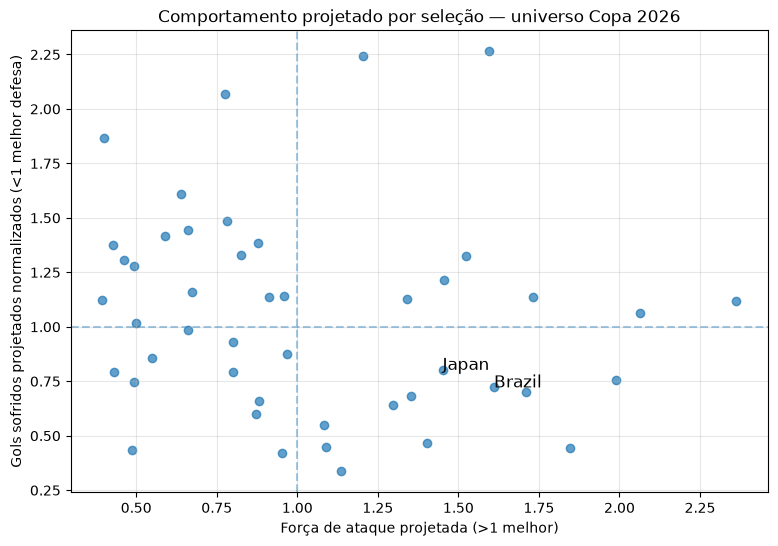

In [14]:
# ============================================================
# Perfil comportamental pré-jogo sem população contaminada
# ============================================================

USE_SQUAD_CONTEXT_IN_TARGET_REPORT = True

def build_behavior_table():
    latest = (
        long_feat[long_feat["match_date"] < MATCH_DATE]
        .sort_values("match_date")
        .groupby(["team_key", "team_name"], as_index=False)
        .tail(1)
    )

    cols_latest = ["team_key", "team_name"] + [
        c for c in latest.columns
        if c.startswith(BASE_FEATURE_PREFIXES)
        or c in ["days_since_last", "performance_score_asof_norm"]
    ]

    latest = latest[cols_latest].drop_duplicates("team_key")

    b = team_strength_forecast.merge(
        latest.drop(columns=["team_name"], errors="ignore"),
        on="team_key",
        how="left"
    )

    if not team_perf_2026.empty:
        b = b.merge(
            team_perf_2026[
                [
                    "team_key", "ppg_2026", "gf_pg_2026", "ga_pg_2026",
                    "gd_pg_2026", "win_rate_2026",
                    "performance_score_2026", "performance_score_2026_norm",
                ]
            ],
            on="team_key",
            how="left"
        )

    if USE_SQUAD_CONTEXT_IN_TARGET_REPORT and not squad_feat.empty:
        # Só para relatório/pré-jogo, não para treino histórico.
        b = b.merge(squad_feat.drop(columns=["team_name"], errors="ignore"), on="team_key", how="left")

    perf_col = "performance_score_2026_norm" if "performance_score_2026_norm" in b.columns else "performance_score_asof_norm"

    b["attack_index"] = b["attack_mu"] * (1 + 0.08 * b.get(perf_col, 0.5).fillna(0.5))
    b["defense_index"] = 1 / b["defense_mu"].replace(0, np.nan)
    b["volatility_index"] = b[["attack_sigma", "defense_sigma"]].mean(axis=1)

    # Squad entra apenas como sinal fraco no relatório do jogo-alvo.
    squad_signal = b.get("squad_affinity_index", pd.Series(0, index=b.index)).fillna(0)
    squad_weight = 0.03 if USE_SQUAD_CONTEXT_IN_TARGET_REPORT else 0.00

    b["overall_strength"] = (
        0.44 * b["attack_index"].fillna(1)
        + 0.37 * b["defense_index"].fillna(1)
        + 0.16 * b.get(perf_col, 0.5).fillna(0.5)
        + squad_weight * squad_signal
    )

    def label(row):
        atk = row.get("attack_mu", 1)
        de = row.get("defense_mu", 1)
        if atk >= 1.20 and de >= 1.05:
            return "agressiva_aberta"
        if atk >= 1.15 and de < 1.00:
            return "forte_equilibrada"
        if atk < 0.95 and de < 0.90:
            return "defensiva_compacta"
        if atk < 0.95 and de >= 1.05:
            return "baixo_ataque_vulneravel"
        return "balanceada"

    b["behavior_profile"] = b.apply(label, axis=1)
    return b.sort_values("overall_strength", ascending=False)


behavior = build_behavior_table()
behavior.to_csv(OUT_DIR / "hybrid_team_behavior_2022_2026_clean.csv", index=False)

display(behavior.head(20))

plt.figure(figsize=(9, 6))
plt.scatter(behavior["attack_mu"], behavior["defense_mu"], alpha=0.7)
for _, r in behavior[behavior["team_name"].isin([HOME_TEAM, AWAY_TEAM])].iterrows():
    plt.annotate(r["team_name"], (r["attack_mu"], r["defense_mu"]), fontsize=12)
plt.axvline(1.0, linestyle="--", alpha=0.4)
plt.axhline(1.0, linestyle="--", alpha=0.4)
plt.xlabel("Força de ataque projetada (>1 melhor)")
plt.ylabel("Gols sofridos projetados normalizados (<1 melhor defesa)")
plt.title("Comportamento projetado por seleção — universo Copa 2026")
plt.grid(True, alpha=0.3)
plt.show()


## 12. Camada de teoria dos jogos / Nash

Se existir `game_theory.py` na pasta do projeto, usamos a implementação dele. Caso contrário, usamos a função equivalente neste notebook.

In [15]:
try:
    from game_theory import stage_multiplier, equilibrium_aggression
    GAME_THEORY_SOURCE = "game_theory.py"
except Exception:
    STAGE_STAKES = {
        "group stage": 0.10,
        "round of 32": 0.20,
        "round of 16": 0.30,
        "quarter-finals": 0.45,
        "semi-finals": 0.65,
        "final": 0.85,
    }
    def equilibrium_aggression(stake: float, strength_ratio: float = 1.0) -> float:
        R, K, C = 1.0, 1.25, 1.60
        risk = C * stake / max(strength_ratio, 1e-6)
        return float(np.clip(R / (K + risk), 0.0, 1.0))
    def stage_multiplier(stage_name: str, strength_ratio: float = 1.0, kappa: float = 0.30) -> float:
        stake = STAGE_STAKES.get(stage_name.lower().strip(), 0.20)
        a_star = equilibrium_aggression(stake, strength_ratio)
        return float(1.0 + kappa * (a_star - 0.5) * 2.0)
    GAME_THEORY_SOURCE = "notebook_fallback"

print("Fonte game theory:", GAME_THEORY_SOURCE)
for st in ["group stage", "round of 32", "round of 16", "quarter-finals", "semi-finals", "final"]:
    print(st, "a*=", round(equilibrium_aggression({"group stage":0.10,"round of 32":0.20,"round of 16":0.30,"quarter-finals":0.45,"semi-finals":0.65,"final":0.85}[st]), 3), "rho=", round(stage_multiplier(st), 3))


Fonte game theory: notebook_fallback
group stage a*= 0.709 rho= 1.126
round of 32 a*= 0.637 rho= 1.082
round of 16 a*= 0.578 rho= 1.047
quarter-finals a*= 0.508 rho= 1.005
semi-finals a*= 0.437 rho= 0.962
final a*= 0.383 rho= 0.93


## 13. Criar vetor do confronto e rodar experts base

In [16]:
# ============================================================
# Vetores do confronto e previsões de cada expert avançado
# ============================================================

def latest_team_row(team):
    tk = norm_key(canonical_team(team))
    lf = long_feat.copy()
    lf["match_date"] = pd.to_datetime(lf["match_date"], errors="coerce")
    g = lf[(lf["team_key"] == tk) & (lf["match_date"] < MATCH_DATE)].sort_values("match_date")
    if g.empty:
        available = sorted(lf["team_key"].dropna().unique().tolist())[:80]
        raise ValueError(f"Sem histórico para {team} / {tk}. Exemplos disponíveis: {available}")
    return g.iloc[-1].copy()


def get_squad_row(team):
    if "squad_feat" not in globals() or squad_feat is None or squad_feat.empty or "team_key" not in squad_feat.columns:
        return None
    tk = norm_key(canonical_team(team))
    s = squad_feat[squad_feat["team_key"] == tk]
    if s.empty:
        return None
    return s.iloc[0]


def current_elo_for_team(team):
    tk = norm_key(canonical_team(team))
    if "model_df_adv" in globals() and "elo_pre" in model_df_adv.columns:
        g = model_df_adv[(model_df_adv["team_key"] == tk) & (model_df_adv["match_date"] < MATCH_DATE)].sort_values("match_date")
        if not g.empty:
            return float(g["elo_pre"].iloc[-1])
    return 1500.0


def make_matchup_row(team, opponent):
    team_row = latest_team_row(team)
    opp_row = latest_team_row(opponent)
    trained_cols = list(feature_cols)

    row = {}

    base_features = set()
    for c in trained_cols:
        if c.startswith("opp_"):
            base_features.add(c.replace("opp_", "", 1))
        elif c.startswith("diff_"):
            base_features.add(c.replace("diff_", "", 1))
        else:
            base_features.add(c)

    # Próprias.
    for base in base_features:
        if base in team_row.index:
            row[base] = team_row[base]

    # Adversário + diferenças.
    for base in base_features:
        if base in opp_row.index:
            row[f"opp_{base}"] = opp_row[base]
        if base in team_row.index and base in opp_row.index:
            row[f"diff_{base}"] = pd.to_numeric(pd.Series([team_row[base]]), errors="coerce").iloc[0] - pd.to_numeric(pd.Series([opp_row[base]]), errors="coerce").iloc[0]

    # Squad time.
    sf_team = get_squad_row(team)
    if sf_team is not None:
        for c in sf_team.index:
            if str(c).startswith("squad_"):
                row[c] = sf_team[c]

    # Squad adversário.
    sf_opp = get_squad_row(opponent)
    if sf_opp is not None:
        for c in sf_opp.index:
            if str(c).startswith("squad_"):
                row[f"opp_{c}"] = sf_opp[c]
                if c in row:
                    try:
                        row[f"diff_{c}"] = float(row[c]) - float(sf_opp[c])
                    except Exception:
                        row[f"diff_{c}"] = np.nan

    # Contexto do jogo.
    match_date_ts = pd.Timestamp(MATCH_DATE)
    row["is_friendly"] = 0
    row["neutral"] = int(bool(NEUTRAL_SITE)) if "NEUTRAL_SITE" in globals() else 1
    row["is_home"] = 0
    row["month"] = int(match_date_ts.month)
    row["days_since_last"] = int((match_date_ts - pd.Timestamp(team_row["match_date"])).days)

    # Elo pré-jogo.
    elo_team = current_elo_for_team(team)
    elo_opp = current_elo_for_team(opponent)
    row["elo_pre"] = elo_team
    row["opp_elo_pre"] = elo_opp
    row["elo_diff"] = elo_team - elo_opp

    X = pd.DataFrame([{c: row.get(c, np.nan) for c in trained_cols}])
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


X_bra = make_matchup_row(HOME_TEAM, AWAY_TEAM)
X_jpn = make_matchup_row(AWAY_TEAM, HOME_TEAM)


def base_lambda_from_rows(X_team, X_opp):
    def getv(X, c, default=np.nan):
        return float(X[c].iloc[0]) if c in X.columns and pd.notna(X[c].iloc[0]) else default
    gf5 = getv(X_team, "gf_avg_5", GLOBAL_GOALS_MEAN)
    opp_ga5 = getv(X_team, "opp_ga_avg_5", GLOBAL_GOALS_MEAN)
    own_gf10 = getv(X_team, "gf_avg_10", gf5)
    return float(np.clip(np.nanmean([gf5, own_gf10, opp_ga5, GLOBAL_GOALS_MEAN]), 0.05, 6.0))


def predict_wdl_proba_from_model(model, X, cols=None):
    Xuse = X[cols] if cols is not None else X
    probs = model.predict_proba(Xuse)[0]
    classes = list(model.classes_) if hasattr(model, "classes_") else list(model.steps[-1][1].classes_)
    d = dict(zip(classes, probs))
    return float(d.get("W", 0.0)), float(d.get("D", 0.0)), float(d.get("L", 0.0))


def expert_score_matrix(expert_name, X_home, X_away, use_prophet_actual=True):
    exp = advanced_experts[expert_name]
    typ = exp["type"]

    if typ == "lambda":
        lh = float(exp["model"].predict(X_home)[0])
        la = float(exp["model"].predict(X_away)[0])
        P = markov_score_distribution(lh, la)

    elif typ == "double_lambda":
        # Geometric mean entre ataque próprio e defesa sofrida pelo adversário.
        lh_for = float(exp["for_model"].predict(X_home)[0])
        la_for = float(exp["for_model"].predict(X_away)[0])
        home_goals_from_away_against = float(exp["against_model"].predict(X_away)[0])
        away_goals_from_home_against = float(exp["against_model"].predict(X_home)[0])
        lh = float(np.sqrt(max(lh_for, 0.03) * max(home_goals_from_away_against, 0.03)))
        la = float(np.sqrt(max(la_for, 0.03) * max(away_goals_from_home_against, 0.03)))
        P = markov_score_distribution(lh, la)

    elif typ in ["wdl", "wdl_elo"]:
        cols = exp.get("cols") if typ == "wdl_elo" else None
        pW, pD, pL = predict_wdl_proba_from_model(exp["model"], X_home, cols=cols)
        lh = base_lambda_from_rows(X_home, X_away)
        la = base_lambda_from_rows(X_away, X_home)
        P0 = markov_score_distribution(lh, la)
        P = reweight_matrix_to_wdl(P0, pW, pD, pL)

    elif typ == "prophet":
        # Este expert será preenchido depois com Prophet real. Aqui fica proxy por rolling.
        lh = base_lambda_from_rows(X_home, X_away)
        la = base_lambda_from_rows(X_away, X_home)
        P = markov_score_distribution(lh, la)

    else:
        raise ValueError(f"Tipo de expert não reconhecido: {typ}")

    P = normalize_matrix(P)
    lh2, la2 = matrix_expected_goals(P)
    p_home, p_draw, p_away = matrix_wdl(P)
    return {
        "expert": expert_name,
        "lambda_home": lh2,
        "lambda_away": la2,
        "p_home_win": p_home,
        "p_draw": p_draw,
        "p_away_win": p_away,
        "matrix": P,
    }


expert_predictions = {name: expert_score_matrix(name, X_bra, X_jpn) for name in advanced_experts.keys() if name != "prophet_markov"}

expert_prediction_summary = pd.DataFrame([
    {k: v for k, v in pred.items() if k != "matrix"}
    for pred in expert_predictions.values()
])
expert_prediction_summary.to_csv(OUT_DIR / "moe_base_expert_predictions_before_prophet.csv", index=False)
display(expert_prediction_summary)

matchup_features = pd.concat([
    X_bra.assign(team=HOME_TEAM, opponent=AWAY_TEAM),
    X_jpn.assign(team=AWAY_TEAM, opponent=HOME_TEAM),
], ignore_index=True)
matchup_features.to_csv(OUT_DIR / "moe_matchup_features_brazil_japan.csv", index=False)


,expert,lambda_home,lambda_away,p_home_win,p_draw,p_away_win
0,nnar_poisson,1.074663,0.784739,0.420171,0.315740,0.264089
1,poisson_double,1.471335,1.293334,0.414571,0.252091,0.333339
2,full_logistic,1.253339,1.265312,0.266765,0.459304,0.273931
3,elo_logistic,1.258260,1.339856,0.298275,0.354612,0.347113


## 14. MoE pairwise em paralelo com Prophet usando cadeia de Markov

In [17]:
# ============================================================
# MoE pairwise + Prophet em paralelo + cadeia de Markov
# ============================================================

def get_strength(team):
    tk = norm_key(canonical_team(team))
    if "team_strength_forecast" in globals() and not team_strength_forecast.empty:
        row = team_strength_forecast[team_strength_forecast["team_key"] == tk]
        if not row.empty:
            return row.iloc[0].to_dict()
    return {"attack_mu": 1.0, "attack_sigma": 0.25, "defense_mu": 1.0, "defense_sigma": 0.25}


def perf_norm(team):
    tk = norm_key(canonical_team(team))
    return float(perf_map.get(tk, 0.5)) if "perf_map" in globals() else 0.5


def overall_strength(team):
    tk = norm_key(canonical_team(team))
    if "behavior" in globals() and not behavior.empty and "overall_strength" in behavior.columns:
        row = behavior[behavior["team_key"] == tk]
        if not row.empty:
            return float(row["overall_strength"].iloc[0])
    return max(current_elo_for_team(team), 1.0) / 1500.0


def prophet_or_recent_samples_for_moe(team, value_col, n=N_PROPHET_MARKOV_SAMPLES, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    ts = team_strength_series(long_feat, team)
    if ts.empty:
        return rng.normal(1.0, 0.25, size=n).clip(0.05, 5.0), "missing_fallback"

    x = ts[["ds", value_col]].dropna().rename(columns={value_col: "y"}).copy()

    if PROPHET_OK and len(x) >= 6 and x["y"].nunique() >= 2:
        try:
            m = Prophet(
                yearly_seasonality=False,
                weekly_seasonality=False,
                daily_seasonality=False,
                uncertainty_samples=n,
                interval_width=0.80,
            )
            m.fit(x)
            future = pd.DataFrame({"ds": [pd.Timestamp(MATCH_DATE)]})
            samples = m.predictive_samples(future)
            if "yhat" in samples:
                arr = np.asarray(samples["yhat"]).ravel()
            else:
                arr = np.asarray(m.predict(future)["yhat"]).ravel()
            arr = arr[np.isfinite(arr)]
            if len(arr) == 0:
                raise ValueError("Prophet retornou vazio")
            if len(arr) < n:
                arr = rng.choice(arr, size=n, replace=True)
            else:
                arr = rng.choice(arr, size=n, replace=False)
            return np.clip(arr.astype(float), 0.05, 5.0), "prophet_predictive_samples"
        except Exception as e:
            pass

    mu, sig = weighted_recent_forecast(ts, value_col, MATCH_DATE)
    return rng.normal(mu, sig, size=n).clip(0.05, 5.0), "recent_weighted_fallback"


def prophet_markov_expert_matrix(n=N_PROPHET_MARKOV_SAMPLES):
    atk_h, src_atk_h = prophet_or_recent_samples_for_moe(HOME_TEAM, "attack_smooth", n=n, seed=RANDOM_SEED + 101)
    def_h, src_def_h = prophet_or_recent_samples_for_moe(HOME_TEAM, "defense_smooth", n=n, seed=RANDOM_SEED + 102)
    atk_a, src_atk_a = prophet_or_recent_samples_for_moe(AWAY_TEAM, "attack_smooth", n=n, seed=RANDOM_SEED + 103)
    def_a, src_def_a = prophet_or_recent_samples_for_moe(AWAY_TEAM, "defense_smooth", n=n, seed=RANDOM_SEED + 104)

    # LSTM residual controlado, se existir na tabela de forecast.
    sh = get_strength(HOME_TEAM)
    sa = get_strength(AWAY_TEAM)
    atk_h = np.clip(atk_h + 0.25 * float(sh.get("lstm_attack_residual", 0.0) or 0.0), 0.05, 5.0)
    def_h = np.clip(def_h + 0.25 * float(sh.get("lstm_defense_residual", 0.0) or 0.0), 0.05, 5.0)
    atk_a = np.clip(atk_a + 0.25 * float(sa.get("lstm_attack_residual", 0.0) or 0.0), 0.05, 5.0)
    def_a = np.clip(def_a + 0.25 * float(sa.get("lstm_defense_residual", 0.0) or 0.0), 0.05, 5.0)

    perf_h = perf_norm(HOME_TEAM)
    perf_a = perf_norm(AWAY_TEAM)
    perf_boost_h = 1.0 + 0.12 * (perf_h - perf_a)
    perf_boost_a = 1.0 + 0.12 * (perf_a - perf_h)

    strength_ratio = overall_strength(HOME_TEAM) / max(overall_strength(AWAY_TEAM), 1e-6)
    rho_stage = stage_multiplier(STAGE, strength_ratio=strength_ratio)
    a_star = equilibrium_aggression(0.20, strength_ratio=strength_ratio)

    lh = np.clip(GLOBAL_GOALS_MEAN * atk_h * def_a * perf_boost_h * rho_stage, 0.05, 8.0)
    la = np.clip(GLOBAL_GOALS_MEAN * atk_a * def_h * perf_boost_a * rho_stage, 0.05, 8.0)

    # Amostra matrizes Markov e faz média. Limita para velocidade.
    mats = []
    for lhi, lai in zip(lh, la):
        mats.append(markov_score_distribution(lhi, lai))
    P = normalize_matrix(np.mean(mats, axis=0))
    eh, ea = matrix_expected_goals(P)
    ph, pd_, pa = matrix_wdl(P)
    return {
        "expert": "prophet_markov",
        "lambda_home": eh,
        "lambda_away": ea,
        "p_home_win": ph,
        "p_draw": pd_,
        "p_away_win": pa,
        "matrix": P,
        "source_home_attack": src_atk_h,
        "source_home_defense": src_def_h,
        "source_away_attack": src_atk_a,
        "source_away_defense": src_def_a,
        "rho_stage": rho_stage,
        "a_star": a_star,
        "strength_ratio": strength_ratio,
        "perf_boost_home": perf_boost_h,
        "perf_boost_away": perf_boost_a,
    }


def validation_matches_for_moe(valid_df, max_matches=400):
    keys = valid_df["match_key"].dropna().unique().tolist()
    # Limita para manter o Optuna rápido.
    keys = keys[-max_matches:]
    rows = []
    for mk in keys:
        g = model_df_adv[model_df_adv["match_key"] == mk].copy()
        if len(g) < 2:
            continue
        if "is_home" in g.columns and g["is_home"].notna().any():
            hg = g[g["is_home"].astype(bool)]
            ag = g[~g["is_home"].astype(bool)]
            if hg.empty or ag.empty:
                continue
            hrow = hg.iloc[0]
            arow = ag.iloc[0]
        else:
            hrow = g.iloc[0]
            arow = g.iloc[1]
        rows.append((
            hrow[feature_cols].to_frame().T,
            arow[feature_cols].to_frame().T,
            int(hrow.get("home_score", hrow.get("goals_for", 0))),
            int(hrow.get("away_score", arow.get("goals_for", 0))),
        ))
    return rows


def build_pair_matrix(expert_a, expert_b, base_predictions):
    Pa = base_predictions[expert_a]["matrix"]
    Pb = base_predictions[expert_b]["matrix"]
    return normalize_matrix(0.5 * Pa + 0.5 * Pb)


MOE_MAX_PAIR_WEIGHT = 0.35
MOE_UNIFORM_SHRINKAGE = 0.25
MOE_CONCENTRATION_PENALTY = 0.18
MOE_ENTROPY_TARGET_FRAC = 0.70

def cap_and_redistribute_weights(w, cap=MOE_MAX_PAIR_WEIGHT):
    """
    Limita concentração: nenhum par pode receber peso maior que cap.
    Redistribui o restante proporcionalmente entre os pares não capados.
    """
    w = np.asarray(w, dtype=float)
    w = np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)
    if w.sum() <= 0:
        return np.ones_like(w) / len(w)

    w = w / w.sum()
    capped = np.zeros_like(w, dtype=bool)

    for _ in range(20):
        over = (w > cap) & (~capped)
        if not over.any():
            break

        capped |= over
        excess = float((w[over] - cap).sum())
        w[over] = cap

        free = ~capped
        if not free.any():
            break

        free_sum = float(w[free].sum())
        if free_sum <= 0:
            w[free] += excess / free.sum()
        else:
            w[free] += excess * (w[free] / free_sum)

    return w / max(w.sum(), 1e-12)


def regularize_moe_weights_from_loss(pair_loss_df, pair_names):
    """
    Converte NLL dos pares em pesos suaves.
    Quando os NLLs são muito próximos, evita fingir que existe vencedor claro.
    """
    loss = pair_loss_df.set_index("pair").loc[pair_names, "score_nll"].astype(float).values
    loss = np.nan_to_num(loss, nan=np.nanmedian(loss))

    # Temperatura aumenta quando a diferença entre pares é pequena.
    spread = float(np.nanstd(loss))
    temperature = max(0.03, 4.0 * spread)

    raw = np.exp(-(loss - loss.min()) / temperature)
    w = raw / raw.sum()

    # Shrink para uniforme: reduz overfitting de uma única validação.
    u = np.ones_like(w) / len(w)
    w = (1.0 - MOE_UNIFORM_SHRINKAGE) * w + MOE_UNIFORM_SHRINKAGE * u

    # Limite máximo por par.
    w = cap_and_redistribute_weights(w, MOE_MAX_PAIR_WEIGHT)
    return w, temperature


def tune_pairwise_moe_weights(valid_df):
    expert_names = list(advanced_experts.keys())
    pairs = list(combinations(expert_names, 2))
    pair_names = [f"{a}+{b}" for a, b in pairs]

    val_matches = validation_matches_for_moe(valid_df)
    if len(val_matches) < 10:
        w = np.ones(len(pair_names)) / len(pair_names)
        out = pd.DataFrame({"pair": pair_names, "weight": w, "source": "equal_fallback_few_validation"})
        out.to_csv(OUT_DIR / "moe_pair_weights.csv", index=False)
        return dict(zip(pair_names, w)), out

    # Pré-computa matrizes por match e por par.
    match_pair_mats = []
    y_scores = []
    for Xh, Xa, gh, ga in val_matches:
        base = {}
        for name in expert_names:
            base[name] = expert_score_matrix(name, Xh, Xa, use_prophet_actual=False)
        pair_mats = [build_pair_matrix(a, b, base) for a, b in pairs]
        match_pair_mats.append(pair_mats)
        y_scores.append((gh, ga))

    # Loss individual por par.
    pair_loss_rows = []
    for pi, pn in enumerate(pair_names):
        losses = []
        briers = []
        for mats, (gh, ga) in zip(match_pair_mats, y_scores):
            P = mats[pi]
            losses.append(score_logloss_from_matrix(P, gh, ga))
            briers.append(wdl_brier_from_matrix(P, gh, ga))
        pair_loss_rows.append({
            "pair": pn,
            "score_nll": float(np.mean(losses)),
            "score_nll_std": float(np.std(losses)),
            "wdl_brier": float(np.mean(briers)),
        })

    pair_loss_df = pd.DataFrame(pair_loss_rows).sort_values("score_nll")
    pair_loss_df["nll_delta_from_best"] = pair_loss_df["score_nll"] - pair_loss_df["score_nll"].min()
    pair_loss_df.to_csv(OUT_DIR / "moe_pair_validation_losses.csv", index=False)

    # Opção regularizada por NLL, sem liberdade excessiva de stacking.
    base_w, temperature = regularize_moe_weights_from_loss(pair_loss_df, pair_names)

    source = "regularized_softmax_loss_with_cap"

    # Optuna opcional: agora com penalização de concentração e cap.
    # Continua usando Optuna, mas impede colapso tipo 0.93 em um único par.
    if OPTUNA_OK and N_MOE_OPTUNA_TRIALS > 0:
        max_entropy = np.log(len(pair_names))
        entropy_target = MOE_ENTROPY_TARGET_FRAC * max_entropy

        def objective(trial):
            raw = np.array([
                trial.suggest_float(f"w_{i}", 1e-4, 1.0, log=True)
                for i in range(len(pair_names))
            ])
            w = raw / raw.sum()
            w = (1.0 - MOE_UNIFORM_SHRINKAGE) * w + MOE_UNIFORM_SHRINKAGE * (np.ones_like(w) / len(w))
            w = cap_and_redistribute_weights(w, MOE_MAX_PAIR_WEIGHT)

            losses = []
            briers = []
            for mats, (gh, ga) in zip(match_pair_mats, y_scores):
                P = normalize_matrix(sum(float(wi) * Mi for wi, Mi in zip(w, mats)))
                losses.append(score_logloss_from_matrix(P, gh, ga))
                briers.append(wdl_brier_from_matrix(P, gh, ga))

            entropy = -float(np.sum(w * np.log(np.maximum(w, 1e-12))))
            concentration = float(np.sum(w ** 2))

            # Penaliza concentração e entropia abaixo do alvo.
            entropy_shortfall = max(0.0, entropy_target - entropy)
            return float(
                np.mean(losses)
                + 0.35 * np.mean(briers)
                + MOE_CONCENTRATION_PENALTY * concentration
                + 0.10 * entropy_shortfall
            )

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
        )
        study.optimize(objective, n_trials=N_MOE_OPTUNA_TRIALS, show_progress_bar=True)

        raw = np.array([study.best_trial.params[f"w_{i}"] for i in range(len(pair_names))])
        opt_w = raw / raw.sum()
        opt_w = (1.0 - MOE_UNIFORM_SHRINKAGE) * opt_w + MOE_UNIFORM_SHRINKAGE * (np.ones_like(opt_w) / len(opt_w))
        opt_w = cap_and_redistribute_weights(opt_w, MOE_MAX_PAIR_WEIGHT)

        # Blenda Optuna regularizado com softmax por NLL para maior estabilidade.
        w = normalize_matrix((0.55 * opt_w + 0.45 * base_w).reshape(1, -1)).ravel()
        w = cap_and_redistribute_weights(w, MOE_MAX_PAIR_WEIGHT)

        source = "regularized_optuna_plus_loss_softmax"
        optuna_meta = {
            "best_trial": int(study.best_trial.number),
            "best_value": float(study.best_value),
        }
    else:
        w = base_w
        optuna_meta = {
            "best_trial": None,
            "best_value": None,
        }

    out = pd.DataFrame({
        "pair": pair_names,
        "weight": w,
        "source": source,
        "max_pair_weight": MOE_MAX_PAIR_WEIGHT,
        "uniform_shrinkage": MOE_UNIFORM_SHRINKAGE,
        "temperature_loss_softmax": temperature,
        **optuna_meta,
    }).merge(pair_loss_df, on="pair", how="left").sort_values("weight", ascending=False)

    out["weight_percent"] = out["weight"] * 100
    out.to_csv(OUT_DIR / "moe_pair_weights.csv", index=False)

    return dict(zip(pair_names, w)), out


# 1) Prophet real em paralelo aos modelos já treinados.
prophet_pred = prophet_markov_expert_matrix(n=N_PROPHET_MARKOV_SAMPLES)
expert_predictions["prophet_markov"] = prophet_pred

base_expert_summary = pd.DataFrame([
    {k: v for k, v in pred.items() if k != "matrix"}
    for pred in expert_predictions.values()
])
base_expert_summary.to_csv(OUT_DIR / "moe_base_expert_predictions_with_prophet.csv", index=False)
display(base_expert_summary)

# 2) Otimiza MoE dos pares em validação temporal.
moe_pair_weights, moe_pair_weight_df = tune_pairwise_moe_weights(valid_adv)
moe_pair_weight_df.to_csv(OUT_DIR / "moe_pair_weights.csv", index=False)
display(moe_pair_weight_df.head(20))

# 3) Gera previsões finais por pares de experts.
expert_names = list(advanced_experts.keys())
pairs = list(combinations(expert_names, 2))


def final_pair_prediction(pair):
    a, b = pair
    P = build_pair_matrix(a, b, expert_predictions)
    eh, ea = matrix_expected_goals(P)
    ph, pd_, pa = matrix_wdl(P)
    return {
        "pair": f"{a}+{b}",
        "expert_a": a,
        "expert_b": b,
        "lambda_home": eh,
        "lambda_away": ea,
        "p_home_win": ph,
        "p_draw": pd_,
        "p_away_win": pa,
        "matrix": P,
    }

if JOBLIB_OK:
    pair_outputs = Parallel(n_jobs=-1)(delayed(final_pair_prediction)(p) for p in pairs)
else:
    pair_outputs = [final_pair_prediction(p) for p in pairs]

pair_output_dict = {p["pair"]: p for p in pair_outputs}

# 4) Mistura final MoE.
score_matrix = normalize_matrix(sum(
    float(moe_pair_weights.get(name, 0.0)) * pair_output_dict[name]["matrix"]
    for name in pair_output_dict
))

expected_home, expected_away = matrix_expected_goals(score_matrix)
p_home, p_draw, p_away = matrix_wdl(score_matrix)
p_home_advance = p_home + p_draw * P_PEN_HOME if KNOCKOUT else np.nan

# Bootstrap simples sobre pares para IC80 do avanço.
rng = np.random.default_rng(RANDOM_SEED)
advance_samples = []
pair_names = list(pair_output_dict.keys())
pair_w = np.array([moe_pair_weights.get(n, 0.0) for n in pair_names], dtype=float)
pair_w = pair_w / max(pair_w.sum(), 1e-12)
for _ in range(800):
    chosen = rng.choice(len(pair_names), size=len(pair_names), replace=True, p=pair_w)
    P_boot = normalize_matrix(sum(pair_output_dict[pair_names[i]]["matrix"] for i in chosen))
    ph, pd_, pa = matrix_wdl(P_boot)
    advance_samples.append(ph + pd_ * P_PEN_HOME if KNOCKOUT else np.nan)
ci_low, ci_high = np.nanquantile(advance_samples, [0.10, 0.90])

# Tabela de placares em porcentagem.
score_rows = []
for i in range(score_matrix.shape[0]):
    for j in range(score_matrix.shape[1]):
        prob = float(score_matrix[i, j])
        score_rows.append({
            "home_goals": i,
            "away_goals": j,
            "prob": prob,
            "prob_percent": prob * 100.0,
            "placar": f"{HOME_TEAM} {i} x {j} {AWAY_TEAM}",
        })
score_counts = pd.DataFrame(score_rows).sort_values("prob", ascending=False).reset_index(drop=True)

# Saídas por par sem matriz.
pair_summary = pd.DataFrame([{k: v for k, v in p.items() if k != "matrix"} for p in pair_outputs])
pair_summary["moe_weight"] = pair_summary["pair"].map(moe_pair_weights).fillna(0.0)
pair_summary = pair_summary.sort_values("moe_weight", ascending=False)
pair_summary.to_csv(OUT_DIR / "moe_pair_predictions_brazil_japan.csv", index=False)
score_counts.to_csv(OUT_DIR / "moe_brazil_japan_score_counts_percent.csv", index=False)

# Compatibilidade com nomes antigos do notebook.
score_counts.to_csv(OUT_DIR / "hybrid_brazil_japan_score_counts_percent.csv", index=False)
score_matrix_df = pd.DataFrame(
    score_matrix,
    index=[f"{HOME_TEAM}_{i}" for i in range(score_matrix.shape[0])],
    columns=[f"{AWAY_TEAM}_{j}" for j in range(score_matrix.shape[1])],
)
score_matrix_df.to_csv(OUT_DIR / "moe_brazil_japan_markov_score_matrix.csv")
score_matrix_df.to_csv(OUT_DIR / "hybrid_brazil_japan_score_matrix_poisson_mean.csv")

pred_summary = pd.DataFrame([{
    "home": HOME_TEAM,
    "away": AWAY_TEAM,
    "match_date": str(pd.Timestamp(MATCH_DATE).date()),
    "stage": STAGE,
    "model_family": "Pairwise MoE: NNAR Poisson + Poisson Double + Full Logistic + Elo-Logistic + Prophet-Markov",
    "markov_minutes": MARKOV_MINUTES,
    "max_goals_markov": MAX_GOALS_MARKOV,
    "expected_goals_home_mc_mean": expected_home,
    "expected_goals_away_mc_mean": expected_away,
    "expected_goals_home_final": expected_home,
    "expected_goals_away_final": expected_away,
    "p_home_win_90": p_home,
    "p_draw_90": p_draw,
    "p_away_win_90": p_away,
    "p_home_advance": p_home_advance,
    "p_home_advance_ci80_low": float(ci_low),
    "p_home_advance_ci80_high": float(ci_high),
    "p_home_win_90_percent": p_home * 100,
    "p_draw_90_percent": p_draw * 100,
    "p_away_win_90_percent": p_away * 100,
    "p_home_advance_percent": p_home_advance * 100 if pd.notna(p_home_advance) else np.nan,
    "prophet_source_home_attack": prophet_pred.get("source_home_attack"),
    "prophet_source_home_defense": prophet_pred.get("source_home_defense"),
    "prophet_source_away_attack": prophet_pred.get("source_away_attack"),
    "prophet_source_away_defense": prophet_pred.get("source_away_defense"),
    "rho_stage": prophet_pred.get("rho_stage"),
    "nash_aggression_a_star": prophet_pred.get("a_star"),
    "strength_ratio_home_away": prophet_pred.get("strength_ratio"),
}])

pred_summary.to_csv(OUT_DIR / "moe_brazil_japan_prediction.csv", index=False)
pred_summary.to_csv(OUT_DIR / "hybrid_brazil_japan_prediction.csv", index=False)

print("Resumo MoE final:")
display(pred_summary.T)
print("Top placares por Markov-MoE:")
display(score_counts.head(20)[["placar", "prob_percent"]].assign(prob_percent=lambda d: d["prob_percent"].round(2)))
print("Pares com maior peso no MoE:")
display(pair_summary.head(15))


22:10:21 - cmdstanpy - INFO - Chain [1] start processing
22:10:21 - cmdstanpy - INFO - Chain [1] done processing
22:10:21 - cmdstanpy - INFO - Chain [1] start processing
22:10:21 - cmdstanpy - INFO - Chain [1] done processing
22:10:21 - cmdstanpy - INFO - Chain [1] start processing
22:10:21 - cmdstanpy - INFO - Chain [1] done processing
22:10:21 - cmdstanpy - INFO - Chain [1] start processing
22:10:21 - cmdstanpy - INFO - Chain [1] done processing


,expert,lambda_home,lambda_away,p_home_win,p_draw,p_away_win,source_home_attack,source_home_defense,source_away_attack,source_away_defense,rho_stage,a_star,strength_ratio,perf_boost_home,perf_boost_away
0,nnar_poisson,1.074663,0.784739,0.420171,0.315740,0.264089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,poisson_double,1.471335,1.293334,0.414571,0.252091,0.333339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,full_logistic,1.253339,1.265312,0.266765,0.459304,0.273931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,elo_logistic,1.258260,1.339856,0.298275,0.354612,0.347113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,prophet_markov,1.905035,1.565396,0.460824,0.202198,0.336978,prophet_predictive_samples,prophet_predictive_samples,prophet_predictive_samples,prophet_predictive_samples,1.09047,0.650784,1.116506,1.0104,0.9896


[I 2026-06-27 22:10:27,394] A new study created in memory with name: no-name-04536ce0-7947-4e00-b04a-a029a487aba0


  0%|          | 0/120 [00:00<?, ?it/s]

[I 2026-06-27 22:10:27,410] Trial 0 finished with value: 3.2888225459857994 and parameters: {'w_0': 0.003148911647956862, 'w_1': 0.6351221010640696, 'w_2': 0.08471801418819976, 'w_3': 0.024810409748678097, 'w_4': 0.00042079886696066364, 'w_5': 0.0004207053950287938, 'w_6': 0.0001707396743152812, 'w_7': 0.29154431891537513, 'w_8': 0.02537815508265665, 'w_9': 0.06796578090758151}. Best is trial 0 with value: 3.2888225459857994.
[I 2026-06-27 22:10:27,422] Trial 1 finished with value: 3.3238144585547045 and parameters: {'w_0': 0.00012087541473056971, 'w_1': 0.7579479953348001, 'w_2': 0.21368329072358744, 'w_3': 0.0007068974950624604, 'w_4': 0.000533703276260396, 'w_5': 0.0005415244119402539, 'w_6': 0.0016480446427978971, 'w_7': 0.012561043700013555, 'w_8': 0.005342937261279773, 'w_9': 0.0014618962793704966}. Best is trial 0 with value: 3.2888225459857994.
[I 2026-06-27 22:10:27,435] Trial 2 finished with value: 3.2337667286324754 and parameters: {'w_0': 0.0280163515871626, 'w_1': 0.000361

...

,0
home,Brazil
away,Japan
match_date,2026-06-29
stage,round of 32
model_family,Pairwise MoE: NNAR Poisson + Poisson Double + ...
markov_minutes,90
max_goals_markov,8
expected_goals_home_mc_mean,1.396454
expected_goals_away_mc_mean,1.284285
expected_goals_home_final,1.396454


Top placares por Markov-MoE:


,placar,prob_percent
0,Brazil 1 x 1 Japan,14.63
1,Brazil 0 x 0 Japan,9.56
2,Brazil 1 x 0 Japan,8.96
3,Brazil 0 x 1 Japan,8.10
4,Brazil 2 x 1 Japan,6.89
5,Brazil 1 x 2 Japan,6.59
6,Brazil 2 x 2 Japan,6.34
7,Brazil 2 x 0 Japan,6.13
8,Brazil 0 x 2 Japan,5.06
9,Brazil 3 x 1 Japan,3.27


Pares com maior peso no MoE:


,pair,expert_a,expert_b,lambda_home,lambda_away,p_home_win,p_draw,p_away_win,moe_weight
4,poisson_double+full_logistic,poisson_double,full_logistic,1.362337,1.279323,0.340668,0.355697,0.303635,0.186224
5,poisson_double+elo_logistic,poisson_double,elo_logistic,1.364797,1.316595,0.356423,0.303351,0.340226,0.174922
9,elo_logistic+prophet_markov,elo_logistic,prophet_markov,1.581648,1.452626,0.379550,0.278405,0.342046,0.152815
7,full_logistic+elo_logistic,full_logistic,elo_logistic,1.255799,1.302584,0.282520,0.406958,0.310522,0.125039
0,nnar_poisson+poisson_double,nnar_poisson,poisson_double,1.272999,1.039037,0.417371,0.283915,0.298714,0.084849
6,poisson_double+prophet_markov,poisson_double,prophet_markov,1.688185,1.429365,0.437697,0.227144,0.335159,0.066220
8,full_logistic+prophet_markov,full_logistic,prophet_markov,1.579187,1.415354,0.363794,0.330751,0.305455,0.060642
2,nnar_poisson+elo_logistic,nnar_poisson,elo_logistic,1.166461,1.062297,0.359223,0.335176,0.305601,0.051746
1,nnar_poisson+full_logistic,nnar_poisson,full_logistic,1.164001,1.025025,0.343468,0.387522,0.269010,0.048967
3,nnar_poisson+prophet_markov,nnar_poisson,prophet_markov,1.489849,1.175068,0.440498,0.258969,0.300534,0.048577


## 15. Visualização da matriz Markov-MoE e placares prováveis

In [18]:
print("Distribuição final de placares Markov-MoE já calculada na seção 14.")
display(score_counts.head(20)[["placar", "prob_percent"]].assign(prob_percent=lambda d: d["prob_percent"].round(2)))

Distribuição final de placares Markov-MoE já calculada na seção 14.


,placar,prob_percent
0,Brazil 1 x 1 Japan,14.63
1,Brazil 0 x 0 Japan,9.56
2,Brazil 1 x 0 Japan,8.96
3,Brazil 0 x 1 Japan,8.10
4,Brazil 2 x 1 Japan,6.89
5,Brazil 1 x 2 Japan,6.59
6,Brazil 2 x 2 Japan,6.34
7,Brazil 2 x 0 Japan,6.13
8,Brazil 0 x 2 Japan,5.06
9,Brazil 3 x 1 Japan,3.27


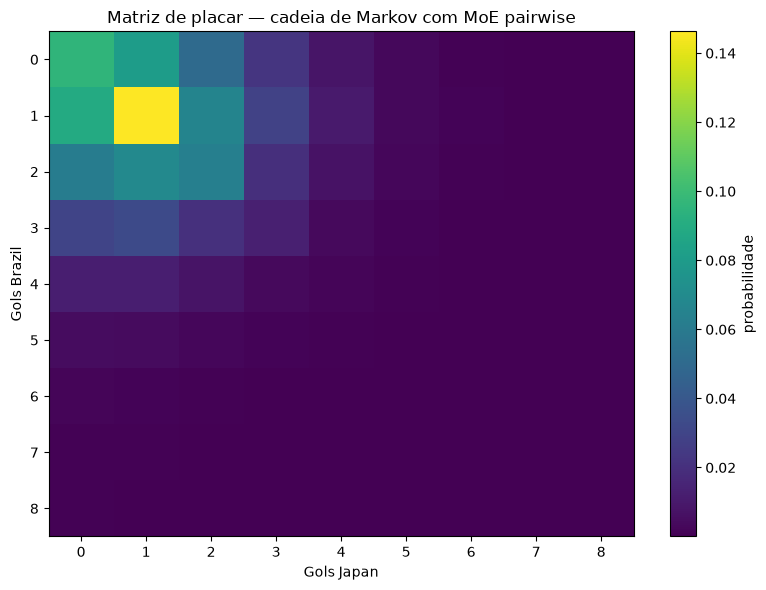

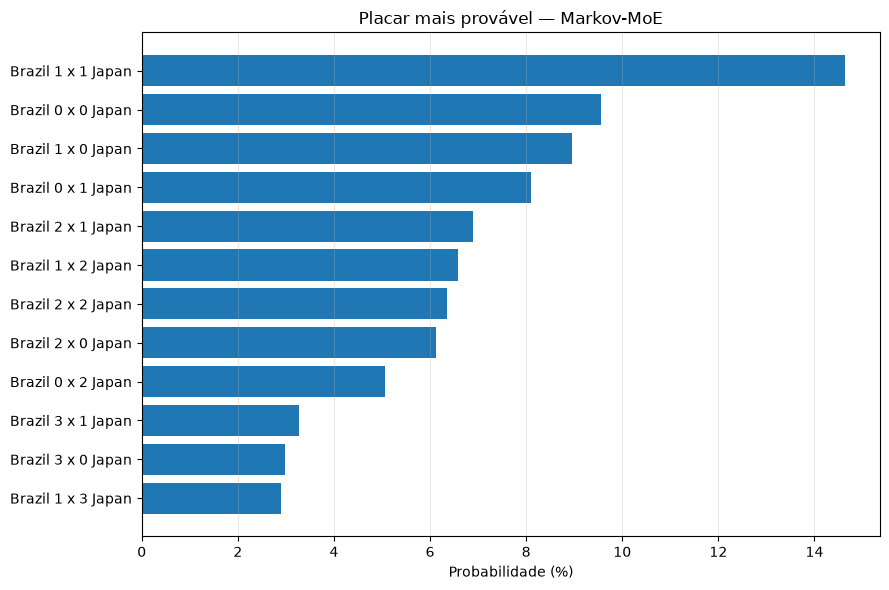

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(score_matrix, aspect="auto")
plt.xticks(range(score_matrix.shape[1]), range(score_matrix.shape[1]))
plt.yticks(range(score_matrix.shape[0]), range(score_matrix.shape[0]))
plt.xlabel(f"Gols {AWAY_TEAM}")
plt.ylabel(f"Gols {HOME_TEAM}")
plt.title("Matriz de placar — cadeia de Markov com MoE pairwise")
plt.colorbar(label="probabilidade")
plt.tight_layout()
plt.show()

top_scores_plot = score_counts.head(12).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top_scores_plot["placar"], top_scores_plot["prob_percent"])
plt.xlabel("Probabilidade (%)")
plt.title("Placar mais provável — Markov-MoE")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 16. Análise de gols por seleção para suporte da previsão

Essa seção resume ataque/defesa e evolução de gols, com foco em Brasil e Japão.

,team_key,team_name,matches,goals_for,goals_against,goal_diff,gf_pg,ga_pg,win_rate,clean_sheet_rate,failed_score_rate,over25_rate,net_goal_power
31,portugal,Portugal,26,54,21,33,2.076923,0.807692,0.538462,0.384615,0.230769,0.576923,1.269231
1,argentina,Argentina,28,49,19,30,1.750000,0.678571,0.642857,0.571429,0.071429,0.357143,1.071429
6,brazil,Brazil,39,77,42,35,1.974359,1.076923,0.512821,0.333333,0.128205,0.538462,0.897436
15,france,France,33,60,31,29,1.818182,0.939394,0.575758,0.393939,0.212121,0.515152,0.878788
38,spain,Spain,30,59,33,26,1.966667,1.100000,0.500000,0.366667,0.166667,0.600000,0.866667
22,japan,Japan,35,64,34,30,1.828571,0.971429,0.514286,0.342857,0.200000,0.514286,0.857143
8,colombia,Colombia,36,61,32,29,1.694444,0.888889,0.583333,0.416667,0.166667,0.527778,0.805556
3,austria,Austria,24,47,29,18,1.958333,1.208333,0.500000,0.208333,0.125000,0.541667,0.750000
14,england,England,22,39,24,15,1.772727,1.090909,0.454545,0.318182,0.181818,0.590909,0.681818
26,netherlands,Netherlands,31,61,43,18,1.967742,1.387097,0.419355,0.193548,0.129032,0.677419,0.580645


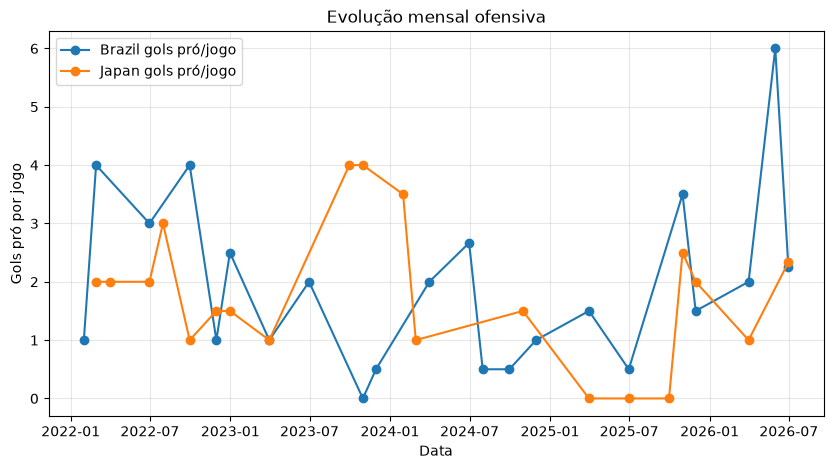

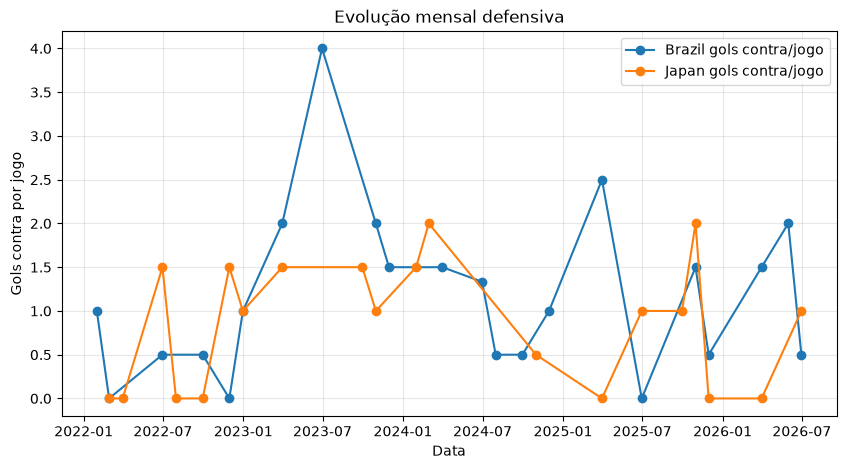

In [20]:
def goals_team_summary_from_long(df):
    s = (df.groupby(["team_key", "team_name"], as_index=False)
           .agg(matches=("match_key", "nunique"),
                goals_for=("goals_for", "sum"),
                goals_against=("goals_against", "sum"),
                goal_diff=("goal_diff", "sum"),
                gf_pg=("goals_for", "mean"),
                ga_pg=("goals_against", "mean"),
                win_rate=("is_win", "mean"),
                clean_sheet_rate=("clean_sheet", "mean"),
                failed_score_rate=("failed_to_score", "mean"),
                over25_rate=("over_25", "mean")))
    s["net_goal_power"] = s["gf_pg"] - s["ga_pg"]
    return s.sort_values("net_goal_power", ascending=False)

gs = goals_team_summary_from_long(long)
gs.to_csv(OUT_DIR / "hybrid_goals_team_summary.csv", index=False)
display(gs.head(20))

focus = long[long["team_name"].isin([HOME_TEAM, AWAY_TEAM])].copy()
focus_monthly = (
    focus.groupby([pd.Grouper(key="match_date", freq="ME"), "team_name"], as_index=False)
    .agg(
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        matches=("match_key", "nunique"),
    )
)
focus_monthly["gf_pg"] = focus_monthly["goals_for"] / focus_monthly["matches"].replace(0, np.nan)
focus_monthly["ga_pg"] = focus_monthly["goals_against"] / focus_monthly["matches"].replace(0, np.nan)

plt.figure(figsize=(10, 5))
for team in [HOME_TEAM, AWAY_TEAM]:
    g = focus_monthly[focus_monthly["team_name"] == team]
    plt.plot(g["match_date"], g["gf_pg"], marker="o", label=f"{team} gols pró/jogo")
plt.title("Evolução mensal ofensiva")
plt.ylabel("Gols pró por jogo")
plt.xlabel("Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
for team in [HOME_TEAM, AWAY_TEAM]:
    g = focus_monthly[focus_monthly["team_name"] == team]
    plt.plot(g["match_date"], g["ga_pg"], marker="o", label=f"{team} gols contra/jogo")
plt.title("Evolução mensal defensiva")
plt.ylabel("Gols contra por jogo")
plt.xlabel("Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 17. Export final e leitura dos resultados

Arquivos gerados em `data/gold/hybrid_forecasting_outputs`:

- `hybrid_team_behavior_2022_2026.csv`: comportamento projetado de cada seleção;
- `team_strength_prophet_lstm_forecast.csv`: força temporal ataque/defesa por seleção;
- `hybrid_brazil_japan_lambdas.csv`: decomposição dos gols esperados;
- `hybrid_brazil_japan_prediction.csv`: probabilidade final do jogo;
- `hybrid_brazil_japan_score_matrix.csv`: matriz de placar;
- `hybrid_matchup_features_brazil_japan.csv`: vetor de entrada usado na regressão.

A previsão final deve ser interpretada como **modelo experimental**, não como verdade. As 16-avos são uma fase inédita em Copa, então a camada de game theory usa um prior fraco para o efeito da fase.

## Auditoria metodológica

In [21]:
audit = {
    "universe_filter": {
        "use_only_world_cup_2026_teams": USE_ONLY_WORLD_CUP_2026_TEAMS,
        "strict_both_teams_in_universe": STRICT_BOTH_TEAMS_IN_UNIVERSE,
        "rows_after_filter": int(len(long)),
        "unique_teams_after_filter": int(pd.concat([long["team_key"], long["opponent_key"]]).nunique()),
        "global_goals_mean_filtered_pre_match": float(GLOBAL_GOALS_MEAN),
    },
    "leakage_controls": {
        "squad_features_in_historical_training": bool(USE_SQUAD_FEATURES_IN_HISTORICAL_TRAINING),
        "performance_2026_as_of_match_date": str(pd.Timestamp(MATCH_DATE).date()),
        "team_strength_series_uses_only_dates_before_match": True,
        "training_performance_weight_is_asof_per_row": True,
    },
    "moe_regularization": {
        "max_pair_weight": float(MOE_MAX_PAIR_WEIGHT),
        "uniform_shrinkage": float(MOE_UNIFORM_SHRINKAGE),
        "concentration_penalty": float(MOE_CONCENTRATION_PENALTY),
    }
}

audit_path = OUT_DIR / "methodology_audit_clean.json"
audit_path.write_text(json.dumps(audit, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(audit, ensure_ascii=False, indent=2))
print("Audit salvo em:", audit_path)


{
  "universe_filter": {
    "use_only_world_cup_2026_teams": true,
    "strict_both_teams_in_universe": true,
    "rows_after_filter": 1174,
    "unique_teams_after_filter": 46,
    "global_goals_mean_filtered_pre_match": 1.3356047700170357
  },
  "leakage_controls": {
    "squad_features_in_historical_training": false,
    "performance_2026_as_of_match_date": "2026-06-29",
    "team_strength_series_uses_only_dates_before_match": true,
    "training_performance_weight_is_asof_per_row": true
  },
  "moe_regularization": {
    "max_pair_weight": 0.35,
    "uniform_shrinkage": 0.25,
    "concentration_penalty": 0.18
  }
}
Audit salvo em: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/methodology_audit_clean.json


In [22]:
print("Arquivos gerados:")
for p in sorted(OUT_DIR.glob("*.csv")):
    print("-", p)

print("\nResumo final MoE + Markov:")
row = pred_summary.iloc[0]
print(f"{HOME_TEAM} x {AWAY_TEAM} — {STAGE} — {pd.Timestamp(MATCH_DATE).date()}")
print(f"Modelo: {row['model_family']}")
print(f"Gols esperados: {HOME_TEAM} {row['expected_goals_home_final']:.2f} x {row['expected_goals_away_final']:.2f} {AWAY_TEAM}")
print(f"P({HOME_TEAM} vence em 90') = {row['p_home_win_90_percent']:.1f}%")
print(f"P(empate em 90') = {row['p_draw_90_percent']:.1f}%")
print(f"P({AWAY_TEAM} vence em 90') = {row['p_away_win_90_percent']:.1f}%")
print(f"P({HOME_TEAM} avança) = {row['p_home_advance_percent']:.1f}% | IC80 {row['p_home_advance_ci80_low']:.1%}–{row['p_home_advance_ci80_high']:.1%}")
print(f"Nash/rho_stage = {row['rho_stage']:.3f} | a* = {row['nash_aggression_a_star']:.3f}")

print("\nTop placares prováveis pelo Markov-MoE:")
for _, r in score_counts.head(10).iterrows():
    print(f"- {r['placar']}: {r['prob_percent']:.2f}%")

print("\nArquivos principais:")
print("-", OUT_DIR / "moe_brazil_japan_prediction.csv")
print("-", OUT_DIR / "moe_brazil_japan_score_counts_percent.csv")
print("-", OUT_DIR / "moe_pair_predictions_brazil_japan.csv")
print("-", OUT_DIR / "moe_pair_weights.csv")


Arquivos gerados:
- /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/hybrid_blend_weights_optuna_trials.csv
- /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/hybrid_brazil_japan_lambda_samples_prophet_mc_sample.csv
- /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/hybrid_brazil_japan_lambdas.csv
- /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/hybrid_brazil_japan_prediction.csv
- /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/hybrid_brazil_japan_score_counts_percent.csv
- /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/hybrid_brazil_japan_score_matrix_poisson_mean.csv
- /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/hybrid_forecasting_outputs/hybrid_goals_team_summary.csv
- /home/perri/Área de 